In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [6]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [7]:
df = pd.read_csv('lotto.csv',
                 names=['nr_losowania', 'data', 'l1', 'l2', 'l3', 'l4', 'l5', 'l6'],
                 dtype={'nr_losowania': str})

df['data'] = pd.to_datetime(df['data'], dayfirst=True)

print(f"Wczytano {len(df)} losowań")
start = df['data'].min()
end = df['data'].max()
print(f"Zakres dat: {start:%Y-%m-%d} - {end:%Y-%m-%d}")

Wczytano 7291 losowań
Zakres dat: 1957-01-27 - 2025-12-23


In [8]:
print(df.head(10))
print(df.dtypes)
print(df.describe())

  nr_losowania       data  l1  l2  l3  l4  l5  l6
0         0001 1957-01-27   8  12  31  39  43  45
1         0002 1957-02-03   5  10  11  22  25  27
2         0003 1957-02-10  18  19  20  26  45  49
3         0004 1957-02-17   2  11  14  37  40  45
4         0005 1957-02-24   8  10  15  35  39  49
5         0006 1957-03-03  24  26  31  35  43  47
6         0007 1957-03-10  13  20  23  29  38  44
7         0008 1957-03-17   8  13  15  22  38  47
8         0009 1957-03-24   3  10  27  29  34  42
9         0010 1957-03-31   4   5   6  13  23  25
nr_losowania            object
data            datetime64[ns]
l1                       int64
l2                       int64
l3                       int64
l4                       int64
l5                       int64
l6                       int64
dtype: object
                                data           l1           l2           l3  \
count                           7291  7291.000000  7291.000000  7291.000000   
mean   1997-11-30 12:23:12.401

In [9]:
duplikaty = df.duplicated().sum()
print(f"\nLiczba zduplikowanych wierszy: {duplikaty}")

braki = df.isnull().sum()
print(f"\nBraki danych:\n{braki}")


Liczba zduplikowanych wierszy: 0

Braki danych:
nr_losowania    0
data            0
l1              0
l2              0
l3              0
l4              0
l5              0
l6              0
dtype: int64


In [10]:
kolumny_liczb = ['l1', 'l2', 'l3', 'l4', 'l5', 'l6']
wszystkie_liczby = df[kolumny_liczb].values.flatten()

min_liczba = wszystkie_liczby.min()
max_liczba = wszystkie_liczby.max()

print(f"\nZakres wylosowanych liczb: {min_liczba} - {max_liczba}")


Zakres wylosowanych liczb: 1 - 49


In [11]:
def sprawdz_unikalne(row):
    liczby = row[kolumny_liczb].values
    return len(set(liczby)) == 6

df['czy_unikalne'] = df.apply(sprawdz_unikalne, axis=1)
nie_unikalne = (~df['czy_unikalne']).sum()

print(f"\nLosowania z duplikatami liczb: {nie_unikalne}")


Losowania z duplikatami liczb: 0


In [12]:
df_long = df.melt(
    id_vars=['nr_losowania', 'data'],
    value_vars=kolumny_liczb,
    var_name='pozycja',
    value_name='liczba'
)

df_long = df_long.sort_values(['data', 'pozycja']).reset_index(drop=True)
print(df_long.head(12))

   nr_losowania       data pozycja  liczba
0          0001 1957-01-27      l1       8
1          0001 1957-01-27      l2      12
2          0001 1957-01-27      l3      31
3          0001 1957-01-27      l4      39
4          0001 1957-01-27      l5      43
5          0001 1957-01-27      l6      45
6          0002 1957-02-03      l1       5
7          0002 1957-02-03      l2      10
8          0002 1957-02-03      l3      11
9          0002 1957-02-03      l4      22
10         0002 1957-02-03      l5      25
11         0002 1957-02-03      l6      27


In [13]:
df['rok'] = df['data'].dt.year
df['miesiac'] = df['data'].dt.month
df['dzien_tygodnia'] = df['data'].dt.day_name()

print(f"\nPierwsze losowanie: {df['data'].min().strftime('%d.%m.%Y')} ({df['data'].min().day_name()})")
print(f"Ostatnie losowanie: {df['data'].max().strftime('%d.%m.%Y')} ({df['data'].max().day_name()})")
print(f"Okres: {(df['data'].max() - df['data'].min()).days} dni ({(df['data'].max() - df['data'].min()).days / 365.25:.1f} lat)")



Pierwsze losowanie: 27.01.1957 (Sunday)
Ostatnie losowanie: 23.12.2025 (Tuesday)
Okres: 25167 dni (68.9 lat)


In [14]:
losowania_per_rok = df.groupby('rok').size()
print(f"\nŚrednia liczba losowań rocznie: {losowania_per_rok.mean():.1f}")
print(f"Min losowań w roku: {losowania_per_rok.min()} (rok {losowania_per_rok.idxmin()})")
print(f"Max losowań w roku: {losowania_per_rok.max()} (rok {losowania_per_rok.idxmax()})")

dni = {
    0: "poniedziałek",
    1: "wtorek",
    2: "środa",
    3: "czwartek",
    4: "piątek",
    5: "sobota",
    6: "niedziela"
}

print("\nLosowania według dni tygodnia:")
print(
    df['data']
    .dt.weekday
    .map(dni)
    .value_counts()
)


Średnia liczba losowań rocznie: 105.7
Min losowań w roku: 47 (rok 1957)
Max losowań w roku: 157 (rok 2008)

Losowania według dni tygodnia:
data
sobota       2551
niedziela    1998
wtorek        956
czwartek      955
środa         831
Name: count, dtype: int64


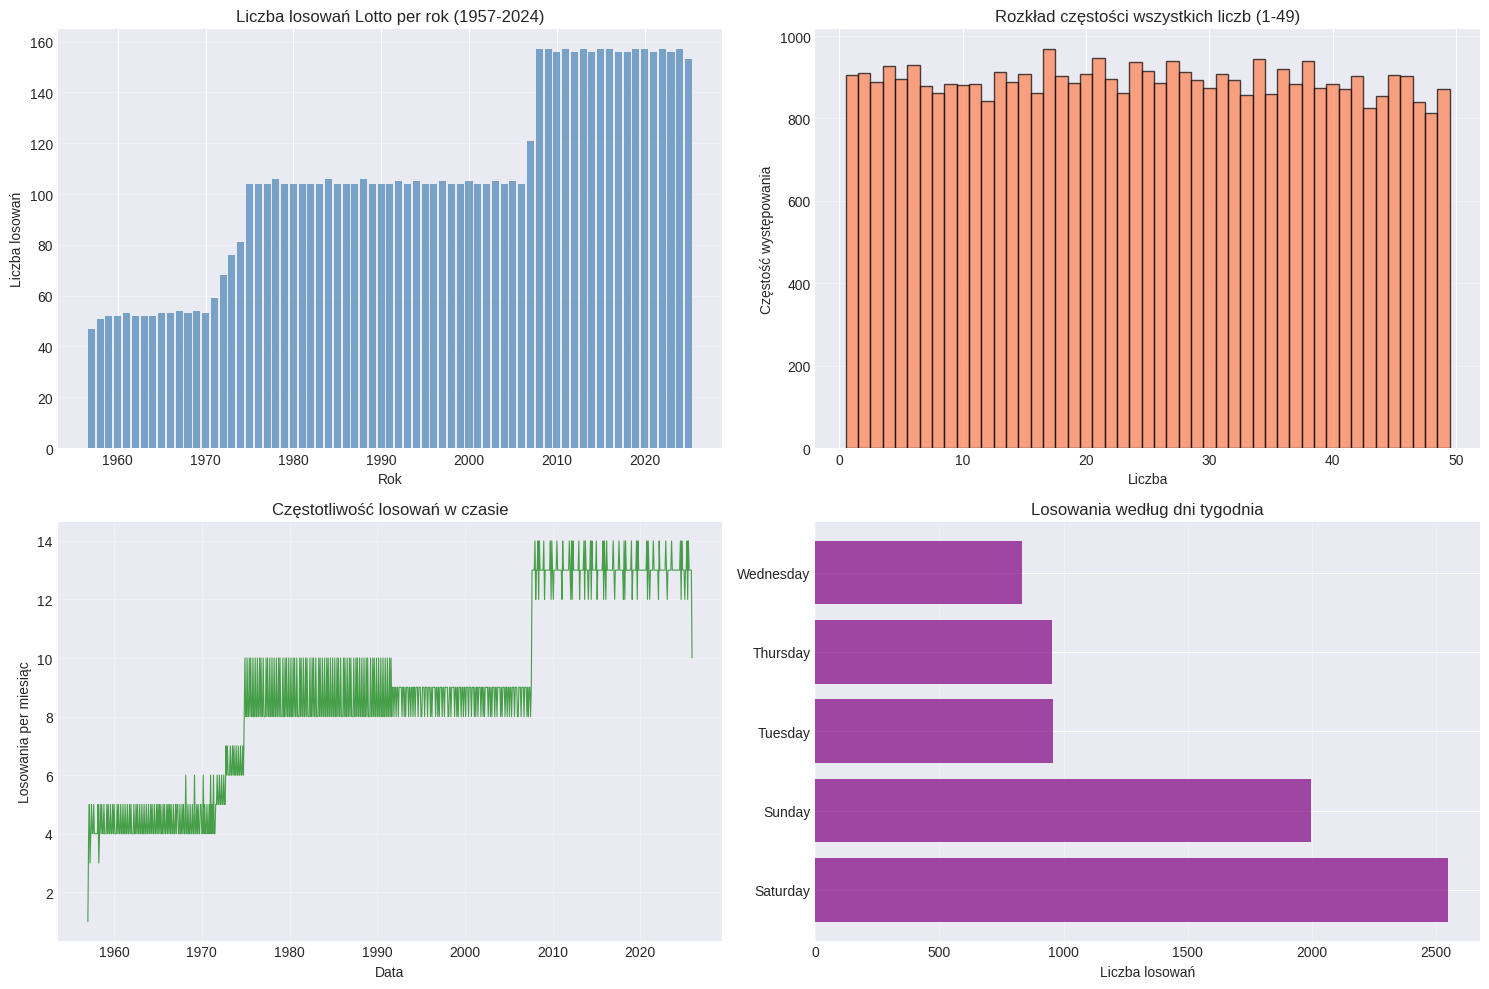

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Liczba losowań per rok
axes[0, 0].bar(losowania_per_rok.index, losowania_per_rok.values, color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Rok')
axes[0, 0].set_ylabel('Liczba losowań')
axes[0, 0].set_title('Liczba losowań Lotto per rok (1957-2024)')
axes[0, 0].grid(axis='y', alpha=0.3)

# Histogram wszystkich wylosowanych liczb
axes[0, 1].hist(wszystkie_liczby, bins=49, range=(0.5, 49.5),
                color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Liczba')
axes[0, 1].set_ylabel('Częstość występowania')
axes[0, 1].set_title('Rozkład częstości wszystkich liczb (1-49)')
axes[0, 1].grid(axis='y', alpha=0.3)

# Timeline losowań
df['rok_miesiac'] = df['data'].dt.to_period('M')
losowania_per_miesiac = df.groupby('rok_miesiac').size()
losowania_per_miesiac.index = losowania_per_miesiac.index.to_timestamp()
axes[1, 0].plot(losowania_per_miesiac.index, losowania_per_miesiac.values,
                linewidth=0.8, color='green', alpha=0.7)
axes[1, 0].set_xlabel('Data')
axes[1, 0].set_ylabel('Losowania per miesiąc')
axes[1, 0].set_title('Częstotliwość losowań w czasie')
axes[1, 0].grid(alpha=0.3)

# Dni tygodnia
dni_count = df['dzien_tygodnia'].value_counts()
axes[1, 1].barh(dni_count.index, dni_count.values, color='purple', alpha=0.7)
axes[1, 1].set_xlabel('Liczba losowań')
axes[1, 1].set_title('Losowania według dni tygodnia')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
n_losowan = len(df)
n_wszystkich_liczb = len(df_long)

print(f"\nWczytano {n_losowan} losowań")
print(f"Łącznie {n_wszystkich_liczb} wylosowanych liczb")

czestosci = df_long['liczba'].value_counts().sort_index()

teoretyczna_czestosc = n_losowan * 6 / 49

print(f"\nTeoretyczna częstość (rozkład równomierny): {teoretyczna_czestosc:.2f}")
print(f"Rzeczywista częstość - zakres: {czestosci.min()} - {czestosci.max()}")
print(f"Średnia częstość: {czestosci.mean():.2f}")
print(f"Odchylenie standardowe: {czestosci.std():.2f}")


Wczytano 7291 losowań
Łącznie 43746 wylosowanych liczb

Teoretyczna częstość (rozkład równomierny): 892.78
Rzeczywista częstość - zakres: 813 - 968
Średnia częstość: 892.78
Odchylenie standardowe: 32.00


In [17]:
# Analiza częstości

ranking = pd.DataFrame({
    'liczba': czestosci.index,
    'częstość': czestosci.values,
    'odchylenie_od_teorii': czestosci.values - teoretyczna_czestosc,
    'procent_odchylenia': ((czestosci.values - teoretyczna_czestosc) / teoretyczna_czestosc * 100)
})

print("\n5 NAJCZĘSTSZYCH LICZB:")
print(ranking.nlargest(5, 'częstość')[['liczba', 'częstość', 'odchylenie_od_teorii']].reset_index(drop=True))

print("\n5 NAJRZADSZYCH LICZB:")
print(ranking.nsmallest(5, 'częstość')[['liczba', 'częstość', 'odchylenie_od_teorii']].reset_index(drop=True))


5 NAJCZĘSTSZYCH LICZB:
   liczba  częstość  odchylenie_od_teorii
0      17       968              75.22449
1      21       948              55.22449
2      34       944              51.22449
3      27       940              47.22449
4      38       940              47.22449

5 NAJRZADSZYCH LICZB:
   liczba  częstość  odchylenie_od_teorii
0      48       813             -79.77551
1      43       825             -67.77551
2      47       839             -53.77551
3      12       843             -49.77551
4      44       855             -37.77551


In [18]:
from scipy import stats
from scipy.stats import chi2_contingency, binom

# Test chi-kwadrat na równomiernośc

# H0: rozkład jest równomierny (każda liczba ma takie samo prawdopodobieństwo)
# H1: rozkład nie jest równomierny

obserwowane = czestosci.values
oczekiwane = np.full(49, teoretyczna_czestosc)

chi2_stat, p_value = stats.chisquare(obserwowane, oczekiwane)
print(f"\nStatystyka chi-kwadrat: {chi2_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Stopnie swobody: {49 - 1}")

alpha = 0.05
if p_value > alpha:
    print(f"\nNie odrzucamy H0 (p > {alpha})")
    print("  Wniosek: Brak podstaw do odrzucenia hipotezy o równomierności.")
    print("  Rozkład jest zgodny z oczekiwanym rozkładem równomiernym.")
else:
    print(f"\nOdrzucamy H0 (p <= {alpha})")
    print("  Wniosek: Rozkład różni się istotnie od równomiernego.")


Statystyka chi-kwadrat: 55.0648
p-value: 0.224901
Stopnie swobody: 48

Nie odrzucamy H0 (p > 0.05)
  Wniosek: Brak podstaw do odrzucenia hipotezy o równomierności.
  Rozkład jest zgodny z oczekiwanym rozkładem równomiernym.


In [19]:
# Przedziały ufności

n_prob = n_losowan
p_sukcesu = 6/49

# Przedział ufności dla rozkładu dwumianowego (przybliżenie normalne)
# CI = p +- z * sqrt(p(1-p)/n)

z = 1.96 #dla 95% CI
odchylenie_std_teorii = np.sqrt(n_prob * p_sukcesu * (1 - p_sukcesu))

dolny_CI = teoretyczna_czestosc - z * odchylenie_std_teorii
gorny_CI = teoretyczna_czestosc + z * odchylenie_std_teorii

print(f"\nTeoretyczna częstość: {teoretyczna_czestosc:.2f}")
print(f"95% przedział ufności: [{dolny_CI:.2f}, {gorny_CI:.2f}]")

# Liczby wykraczające poza przedział:
ranking['w_przedziale_CI'] = (
    (ranking['częstość'] >= dolny_CI) &
    (ranking['częstość'] <= gorny_CI)
)

liczby_poza_CI = ranking[~ranking['w_przedziale_CI']]

if len(liczby_poza_CI) > 0:
    print(f"\nLiczby poza przedziałem ufności ({len(liczby_poza_CI)}):")
    print(liczby_poza_CI[['liczba', 'częstość', 'odchylenie_od_teorii']].reset_index(drop=True))
else:
    print("\nWszystkie liczby mieszczą się w przedziale ufności!")


Teoretyczna częstość: 892.78
95% przedział ufności: [837.91, 947.64]

Liczby poza przedziałem ufności (4):
   liczba  częstość  odchylenie_od_teorii
0      17       968              75.22449
1      21       948              55.22449
2      43       825             -67.77551
3      48       813             -79.77551


In [20]:
# Standaryzowane reszty (z-scores)

# z = (obserwowane - oczekiwane) / sqrt(oczekiwane)

ranking['z_score'] = (ranking['częstość'] - teoretyczna_czestosc) / np.sqrt(teoretyczna_czestosc)
print("\nInterpretacja z-score:")
print("  |z| < 2: normalne odchylenie")
print("  |z| >= 2: potencjalnie nietypowe (p < 0.05)")
print("  |z| >= 3: bardzo nietypowe (p < 0.001)")

nietypowe_2sigma = ranking[np.abs(ranking['z_score']) >= 2]
nietypowe_3sigma = ranking[np.abs(ranking['z_score']) >= 3]

print(f"\nLiczby z |z| >= 2 ({len(nietypowe_2sigma)}):")
if len(nietypowe_2sigma) > 0:
    print(nietypowe_2sigma[['liczba', 'częstość', 'z_score']].sort_values('z_score', ascending=False).reset_index(drop=True))
else:
    print("  Brak")

print(f"\nLiczby z |z| >= 3 ({len(nietypowe_3sigma)}):")
if len(nietypowe_3sigma) > 0:
    print(nietypowe_3sigma[['liczba', 'częstość', 'z_score']].sort_values('z_score', ascending=False).reset_index(drop=True))
else:
    print("  Brak")


Interpretacja z-score:
  |z| < 2: normalne odchylenie
  |z| >= 2: potencjalnie nietypowe (p < 0.05)
  |z| >= 3: bardzo nietypowe (p < 0.001)

Liczby z |z| >= 2 (3):
   liczba  częstość   z_score
0      17       968  2.517608
1      43       825 -2.268306
2      48       813 -2.669921

Liczby z |z| >= 3 (0):
  Brak


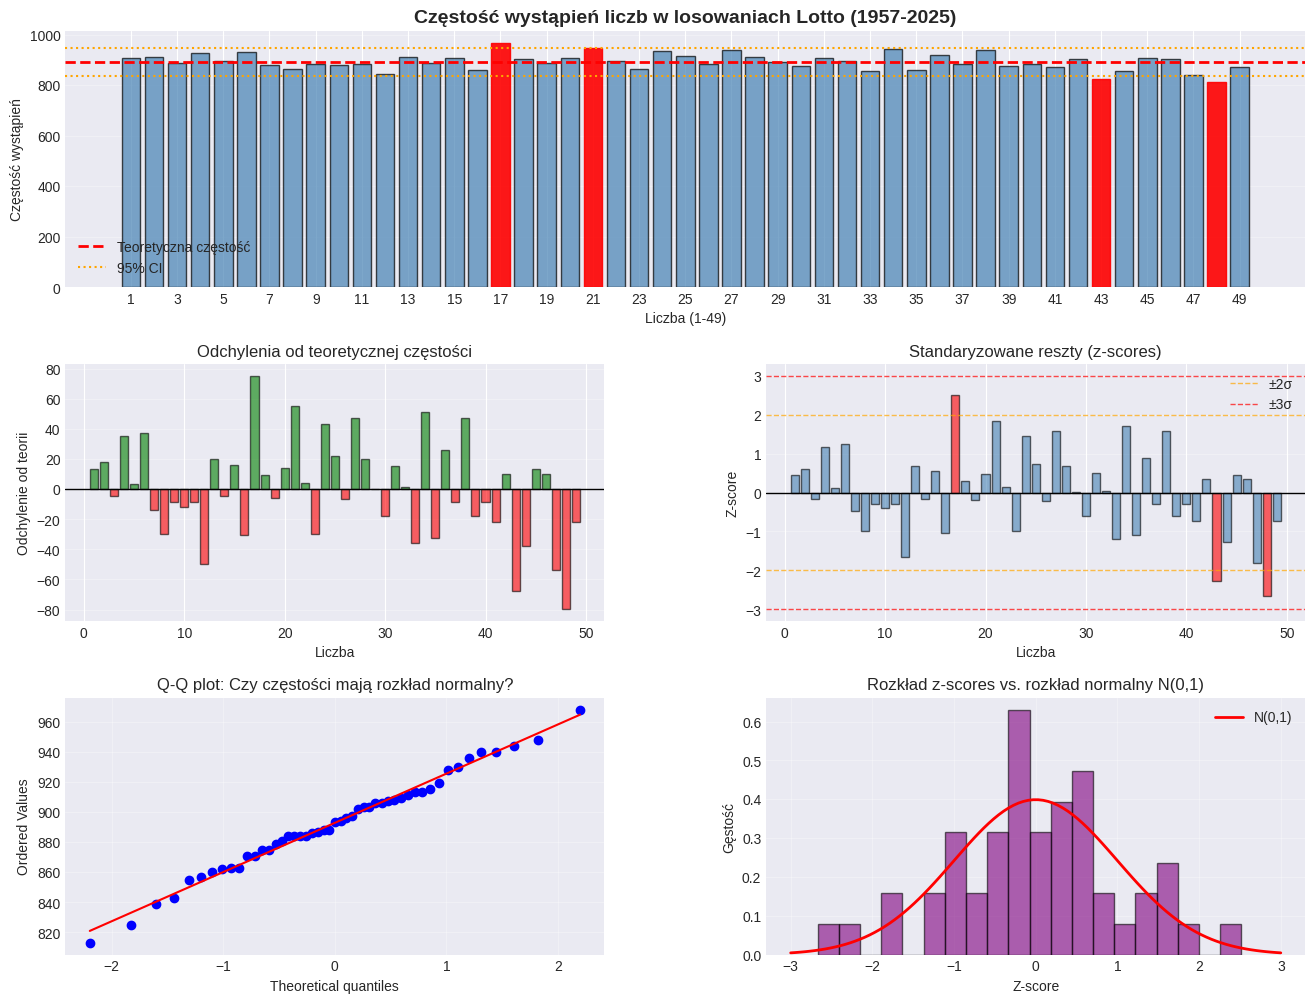

In [21]:
# Wizualizacje

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Histogram częstości z linią teoretyczną
ax1 = fig.add_subplot(gs[0, :])
bars = ax1.bar(ranking['liczba'], ranking['częstość'], color='steelblue', alpha=0.7, edgecolor='black')
ax1.axhline(teoretyczna_czestosc, color='red', linestyle='--', linewidth=2, label='Teoretyczna częstość')
ax1.axhline(dolny_CI, color='orange', linestyle=':', linewidth=1.5, label='95% CI')
ax1.axhline(gorny_CI, color='orange', linestyle=':', linewidth=1.5)
for idx, row in ranking.iterrows():
    if not row['w_przedziale_CI']:
        bars[row['liczba']-1].set_color('red')
        bars[row['liczba']-1].set_alpha(0.9)

ax1.set_xlabel('Liczba (1-49)')
ax1.set_ylabel('Częstość wystąpień')
ax1.set_title('Częstość wystąpień liczb w losowaniach Lotto (1957-2025)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticks(range(1, 50, 2))

# Odchylenia od teorii
ax2 = fig.add_subplot(gs[1, 0])
colors = ['red' if x < 0 else 'green' for x in ranking['odchylenie_od_teorii']]
ax2.bar(ranking['liczba'], ranking['odchylenie_od_teorii'], color=colors, alpha=0.6, edgecolor='black')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_xlabel('Liczba')
ax2.set_ylabel('Odchylenie od teorii')
ax2.set_title('Odchylenia od teoretycznej częstości')
ax2.grid(axis='y', alpha=0.3)

# Z-scores
ax3 = fig.add_subplot(gs[1, 1])
colors_z = ['red' if abs(x) >= 2 else 'steelblue' for x in ranking['z_score']]
ax3.bar(ranking['liczba'], ranking['z_score'], color=colors_z, alpha=0.6, edgecolor='black')
ax3.axhline(0, color='black', linewidth=1)
ax3.axhline(2, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='±2σ')
ax3.axhline(-2, color='orange', linestyle='--', linewidth=1, alpha=0.7)
ax3.axhline(3, color='red', linestyle='--', linewidth=1, alpha=0.7, label='±3σ')
ax3.axhline(-3, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax3.set_xlabel('Liczba')
ax3.set_ylabel('Z-score')
ax3.set_title('Standaryzowane reszty (z-scores)')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# QQ-plot (porównanie z rozkładem teoretycznym)
ax4 = fig.add_subplot(gs[2, 0])
stats.probplot(ranking['częstość'], dist="norm", plot=ax4)
ax4.set_title('Q-Q plot: Czy częstości mają rozkład normalny?')
ax4.grid(alpha=0.3)

# Rozkład z-scores (powinien być zbliżony do N(0,1))
ax5 = fig.add_subplot(gs[2, 1])
ax5.hist(ranking['z_score'], bins=20, color='purple', alpha=0.6, edgecolor='black', density=True)
x = np.linspace(-3, 3, 100)
ax5.plot(x, stats.norm.pdf(x, 0, 1), 'r-', linewidth=2, label='N(0,1)')
ax5.set_xlabel('Z-score')
ax5.set_ylabel('Gęstość')
ax5.set_title('Rozkład z-scores vs. rozkład normalny N(0,1)')
ax5.legend()
ax5.grid(alpha=0.3)

plt.show()


In [22]:
print("Interpretacja wyników")

# Wskaźnik równomierności (coefficient of variation)
cv = (czestosci.std() / czestosci.mean()) * 100

print(f"""
Podsumowanie:
- Współczynnik zmienności (CV): {cv:.2f}%
  (Im bliżej 0%, tym bardziej równomierny rozkład)

- Test chi-kwadrat: {'PASS' if p_value > 0.05 else 'FAIL'}
  (p = {p_value:.6f})

- Liczby poza 95% CI: {len(liczby_poza_CI)} z 49 ({len(liczby_poza_CI)/49*100:.1f}%)
  (Oczekiwane ~2.5 z 49, czyli ~5%)

- Liczby z |z| >= 2: {len(nietypowe_2sigma)} z 49 ({len(nietypowe_2sigma)/49*100:.1f}%)
  (Oczekiwane ~2.5 z 49, czyli ~5%)
""")

print(f"""
Najczęstsza liczba: {ranking.iloc[ranking['częstość'].argmax()]['liczba']:.0f} ({ranking['częstość'].max()} wystąpień)
Najrzadsza liczba: {ranking.iloc[ranking['częstość'].argmin()]['liczba']:.0f} ({ranking['częstość'].min()} wystąpień)
Różnica: {ranking['częstość'].max() - ranking['częstość'].min()} wystąpień
""")


Interpretacja wyników

Podsumowanie:
- Współczynnik zmienności (CV): 3.58%
  (Im bliżej 0%, tym bardziej równomierny rozkład)
  
- Test chi-kwadrat: PASS
  (p = 0.224901)
  
- Liczby poza 95% CI: 4 z 49 (8.2%)
  (Oczekiwane ~2.5 z 49, czyli ~5%)
  
- Liczby z |z| >= 2: 3 z 49 (6.1%)
  (Oczekiwane ~2.5 z 49, czyli ~5%)


Najczęstsza liczba: 17 (968 wystąpień)
Najrzadsza liczba: 48 (813 wystąpień)
Różnica: 155 wystąpień



In [23]:
# Analiza par liczb

from itertools import combinations
from collections import Counter

wszystkie_pary = []
for idx, row in df.iterrows():
  liczby = sorted(row[kolumny_liczb].values)
  pary_z_losowania = list(combinations(liczby, 2))
  wszystkie_pary.extend(pary_z_losowania)

licznik_par = Counter(wszystkie_pary)
print(f"Wygenerowano {len(wszystkie_pary)} par z {n_losowan} losowań")
print(f"Każde losowanie = C(6,2) = 15 par")
print(f"Liczba unikalnych par: {len(licznik_par)}")
print(f"Maksymalnie możliwych: C(49,2) = {49*48//2}")

Wygenerowano 109365 par z 7291 losowań
Każde losowanie = C(6,2) = 15 par
Liczba unikalnych par: 1176
Maksymalnie możliwych: C(49,2) = 1176


In [24]:
# Teoretyczna częstość pary
# Prawdopodobieństwo wylosowania konkretnej pary = C(47,4) / C(49,6)
# Oczekiwana liczba wystąpień = n_losowan * P

from math import comb
P_para = comb(47,4) / comb(49,6)
teoretyczna_czestosc_pary = n_losowan * P_para
print(f"\nTeoretyczna częstość każdej pary: {teoretyczna_czestosc_pary:.2f}")

df_pary = pd.DataFrame([
    {'para': para, 'częstość': freq}
    for para, freq in licznik_par.items()
]).sort_values('częstość', ascending=False)

df_pary['odchylenie'] = df_pary['częstość'] - teoretyczna_czestosc_pary
df_pary['z_score'] = (df_pary['częstość'] - teoretyczna_czestosc_pary) / np.sqrt(teoretyczna_czestosc_pary)

print(f"\nŚrednia częstość par: {df_pary['częstość'].mean():.2f}")
print(f"Odchylenie standardowe: {df_pary['częstość'].std():.2f}")

print("\n10 najczęstszych par:")
print(df_pary.head(10)[['para', 'częstość', 'odchylenie', 'z_score']])

print("\n10 najrzadszych par:")
print(df_pary.tail(10)[['para', 'częstość', 'odchylenie', 'z_score']])



Teoretyczna częstość każdej pary: 93.00

Średnia częstość par: 93.00
Odchylenie standardowe: 9.87

10 najczęstszych par:
          para  częstość  odchylenie   z_score
779   (31, 42)       123   30.002551  3.111162
155   (21, 39)       121   28.002551  2.903769
861   (17, 26)       120   27.002551  2.800073
1035   (7, 46)       120   27.002551  2.800073
756   (17, 21)       119   26.002551  2.696376
353    (1, 17)       119   26.002551  2.696376
944    (9, 18)       118   25.002551  2.592679
1018   (4, 20)       118   25.002551  2.592679
615    (6, 42)       117   24.002551  2.488983
383    (6, 16)       117   24.002551  2.488983

10 najrzadszych par:
          para  częstość  odchylenie   z_score
429    (9, 12)        71  -21.997449 -2.281060
506   (11, 47)        70  -22.997449 -2.384757
703   (23, 45)        70  -22.997449 -2.384757
1144  (13, 48)        69  -23.997449 -2.488454
741   (32, 43)        69  -23.997449 -2.488454
711   (44, 48)        68  -24.997449 -2.592150
789    (8,

In [25]:
# Test statystyczny dla par
pary_2sigma = df_pary[np.abs(df_pary['z_score']) >= 2]
pary_3sigma = df_pary[np.abs(df_pary['z_score']) >= 3]

print(f"\nPary z |z| >= 2: {len(pary_2sigma)} z {len(df_pary)} ({len(pary_2sigma)/len(df_pary)*100:.1f}%)")
print(f"  Oczekiwane przy losowości: ~5%")

if len(pary_2sigma) > 0:
    print("\nEkstremalne pary (|z| >= 2):")
    print(pary_2sigma[['para', 'częstość', 'z_score']].head(10))

print(f"\nPary z |z| >= 3: {len(pary_3sigma)} ({len(pary_3sigma)/len(df_pary)*100:.1f}%)")
print(f"  Oczekiwane przy losowości: ~0.3%")

if len(pary_3sigma) > 0:
    print("\nSkrajnie nietypowe pary:")
    print(pary_3sigma[['para', 'częstość', 'z_score']])

print(f"""
Testujemy {len(df_pary)} par jednocześnie!
Przy 5% poziomie istotności oczekujemy ~{len(df_pary)*0.05:.0f} "fałszywych alarmów".
Znalezienie kilku par z |z| >= 2 nie oznacza, że generator jest tendencyjny.
To normalny efekt statystyczny przy tak wielu testach (multiple comparison problem).

Nie powinniśmy wyciągać wniosków o "szczęśliwych parach" z tych danych.
""")


Pary z |z| >= 2: 60 z 1176 (5.1%)
  Oczekiwane przy losowości: ~5%

Ekstremalne pary (|z| >= 2):
          para  częstość   z_score
779   (31, 42)       123  3.111162
155   (21, 39)       121  2.903769
861   (17, 26)       120  2.800073
1035   (7, 46)       120  2.800073
756   (17, 21)       119  2.696376
353    (1, 17)       119  2.696376
944    (9, 18)       118  2.592679
1018   (4, 20)       118  2.592679
615    (6, 42)       117  2.488983
383    (6, 16)       117  2.488983

Pary z |z| >= 3: 1 (0.1%)
  Oczekiwane przy losowości: ~0.3%

Skrajnie nietypowe pary:
         para  częstość   z_score
779  (31, 42)       123  3.111162

Testujemy 1176 par jednocześnie!
Przy 5% poziomie istotności oczekujemy ~59 "fałszywych alarmów".
Znalezienie kilku par z |z| >= 2 nie oznacza, że generator jest tendencyjny.
To normalny efekt statystyczny przy tak wielu testach (multiple comparison problem).

Nie powinniśmy wyciągać wniosków o "szczęśliwych parach" z tych danych.



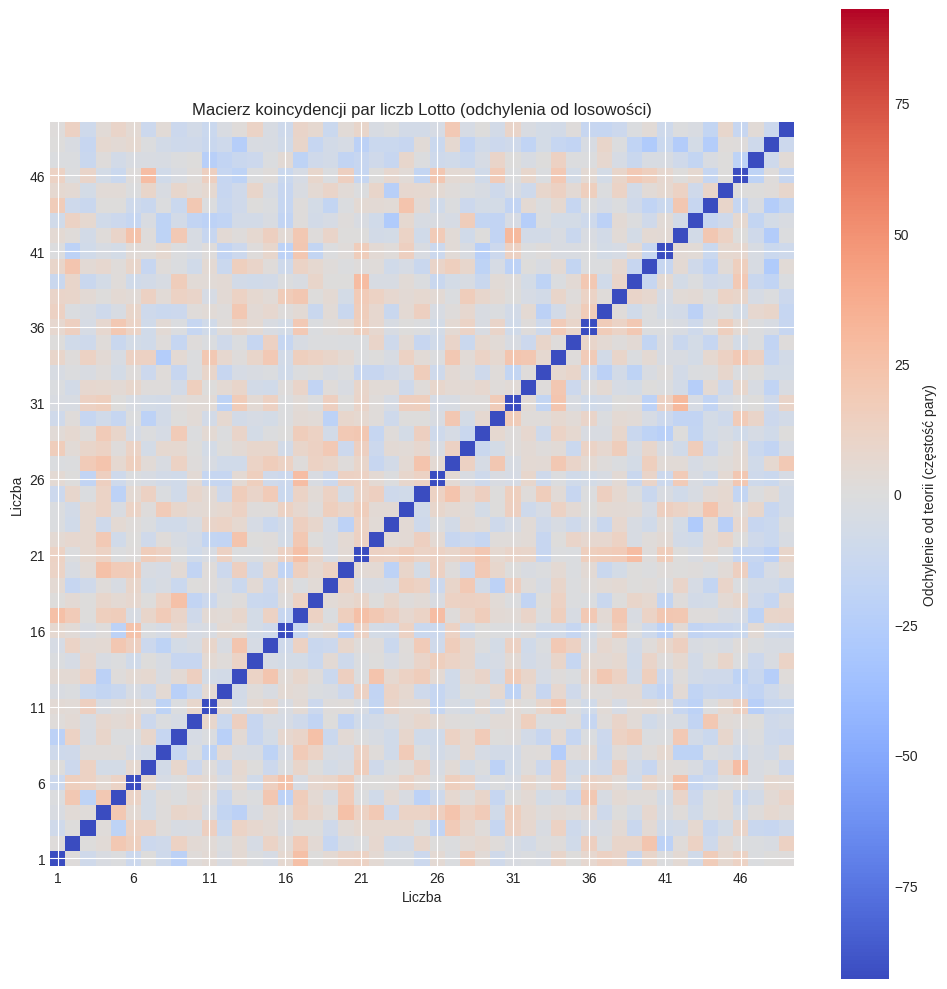

In [26]:
# Macierz koincydencji

macierz = np.zeros((49,49))
for para, freq in licznik_par.items():
  i, j = para
  macierz[i-1, j-1] = freq
  macierz[j-1, i-1] = freq

macierz_norm = macierz - teoretyczna_czestosc_pary

abs_max = np.max(np.abs(macierz_norm))

plt.figure(figsize=(10, 10))

plt.imshow(
    macierz_norm,
    cmap="coolwarm",      # czerwony = częściej, niebieski = rzadziej
    vmin=-abs_max,
    vmax=abs_max,
    origin="lower"
)

plt.colorbar(label="Odchylenie od teorii (częstość pary)")

plt.title("Macierz koincydencji par liczb Lotto (odchylenia od losowości)")
plt.xlabel("Liczba")
plt.ylabel("Liczba")

# Ticks co 5 liczb, żeby nie było śmietnika
ticks = np.arange(0, 49, 5)
labels = np.arange(1, 50, 5)
plt.xticks(ticks, labels)
plt.yticks(ticks, labels)

plt.tight_layout()
plt.show()


In [27]:
# Analiza trójek

wszystkie_trojki = []

for idx, row in df.iterrows():
    liczby = sorted(row[kolumny_liczb].values)
    trojki_z_losowania = list(combinations(liczby, 3))
    wszystkie_trojki.extend(trojki_z_losowania)

licznik_trojek = Counter(wszystkie_trojki)

print(f"Wygenerowano {len(wszystkie_trojki)} trójek")
print(f"(Każde losowanie = C(6,3) = 20 trójek)")
print(f"Liczba unikalnych trójek: {len(licznik_trojek)}")
print(f"(Maksymalnie możliwych: C(49,3) = {comb(49, 3)})")

P_trojka = comb(46, 3) / comb(49, 6)
teoretyczna_czestosc_trojki = n_losowan * P_trojka

print(f"\nTeoretyczna częstość każdej trójki: {teoretyczna_czestosc_trojki:.4f}")

df_trojki = pd.DataFrame([
    {'trojka': trojka, 'częstość': freq}
    for trojka, freq in licznik_trojek.items()
]).sort_values('częstość', ascending=False)

print(f"\nŚrednia częstość trójek: {df_trojki['częstość'].mean():.2f}")
print(f"Max częstość trójki: {df_trojki['częstość'].max()}")

print("\n10 najczęstszych trójek:")
print(df_trojki.head(10))

print("\n10 najrzadszych trójek:")
print(df_trojki.tail(10))

print("\nRozkład częstości trójek:")
print(df_trojki['częstość'].value_counts().sort_index().head(10))


Wygenerowano 145820 trójek
(Każde losowanie = C(6,3) = 20 trójek)
Liczba unikalnych trójek: 18417
(Maksymalnie możliwych: C(49,3) = 18424)

Teoretyczna częstość każdej trójki: 7.9147

Średnia częstość trójek: 7.92
Max częstość trójki: 21

10 najczęstszych trójek:
             trojka  częstość
2276    (1, 17, 38)        21
5396    (1, 28, 38)        21
9924   (10, 11, 24)        20
7546   (19, 24, 41)        19
3214   (21, 29, 39)        19
1867   (17, 21, 29)        19
3551    (4, 20, 22)        19
5515   (31, 38, 42)        19
13327  (21, 39, 41)        19
2958   (18, 20, 29)        19

10 najrzadszych trójek:
             trojka  częstość
18411  (34, 42, 48)         1
18413    (3, 8, 13)         1
18369  (11, 33, 39)         1
18415   (4, 13, 36)         1
18414  (17, 45, 47)         1
18373    (1, 6, 41)         1
18352   (7, 17, 47)         1
18399    (2, 4, 12)         1
18416  (23, 34, 37)         1
18402    (1, 9, 25)         1

Rozkład częstości trójek:
częstość
1       51
2   

In [28]:
from math import comb, sqrt

P_trojka = comb(46, 3) / comb(49, 6)
E = n_losowan * P_trojka    # teoretyczna częstość jednej trójki

print(f"Teoretyczna częstość jednej trójki: {E:.4f}")

import pandas as pd

punkty = []

for (a, b, c), freq in licznik_trojek.items():
    z = (freq - E) / sqrt(E) if E > 0 else 0
    punkty.append((a, b, c, z, freq))

df3d = pd.DataFrame(punkty, columns=["a", "b", "c", "z", "freq"])

df3d.reindex(df3d.z.abs().sort_values(ascending=False).index).head(10)

import plotly.graph_objects as go

axis_min = 1
axis_max = 49
zmax = df3d["z"].abs().max()

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=df3d["a"],
            y=df3d["b"],
            z=df3d["c"],
            mode="markers",
            marker=dict(
                size=4,
                color=df3d["z"],
                colorscale="RdBu",
                cmin=-zmax,
                cmax=zmax,
                colorbar=dict(title="Z-score"),
                opacity=0.8
            )
        )
    ]
)

fig.update_layout(
    title="Wizualizacja 3D trójek",
    scene=dict(
        xaxis=dict(title="Liczba A", range=[axis_min, axis_max]),
        yaxis=dict(title="Liczba B", range=[axis_min, axis_max]),
        zaxis=dict(title="Liczba C", range=[axis_min, axis_max]),
        aspectmode="cube"
    ),
    width=900,
    height=900
)

fig.show()



Teoretyczna częstość jednej trójki: 7.9147


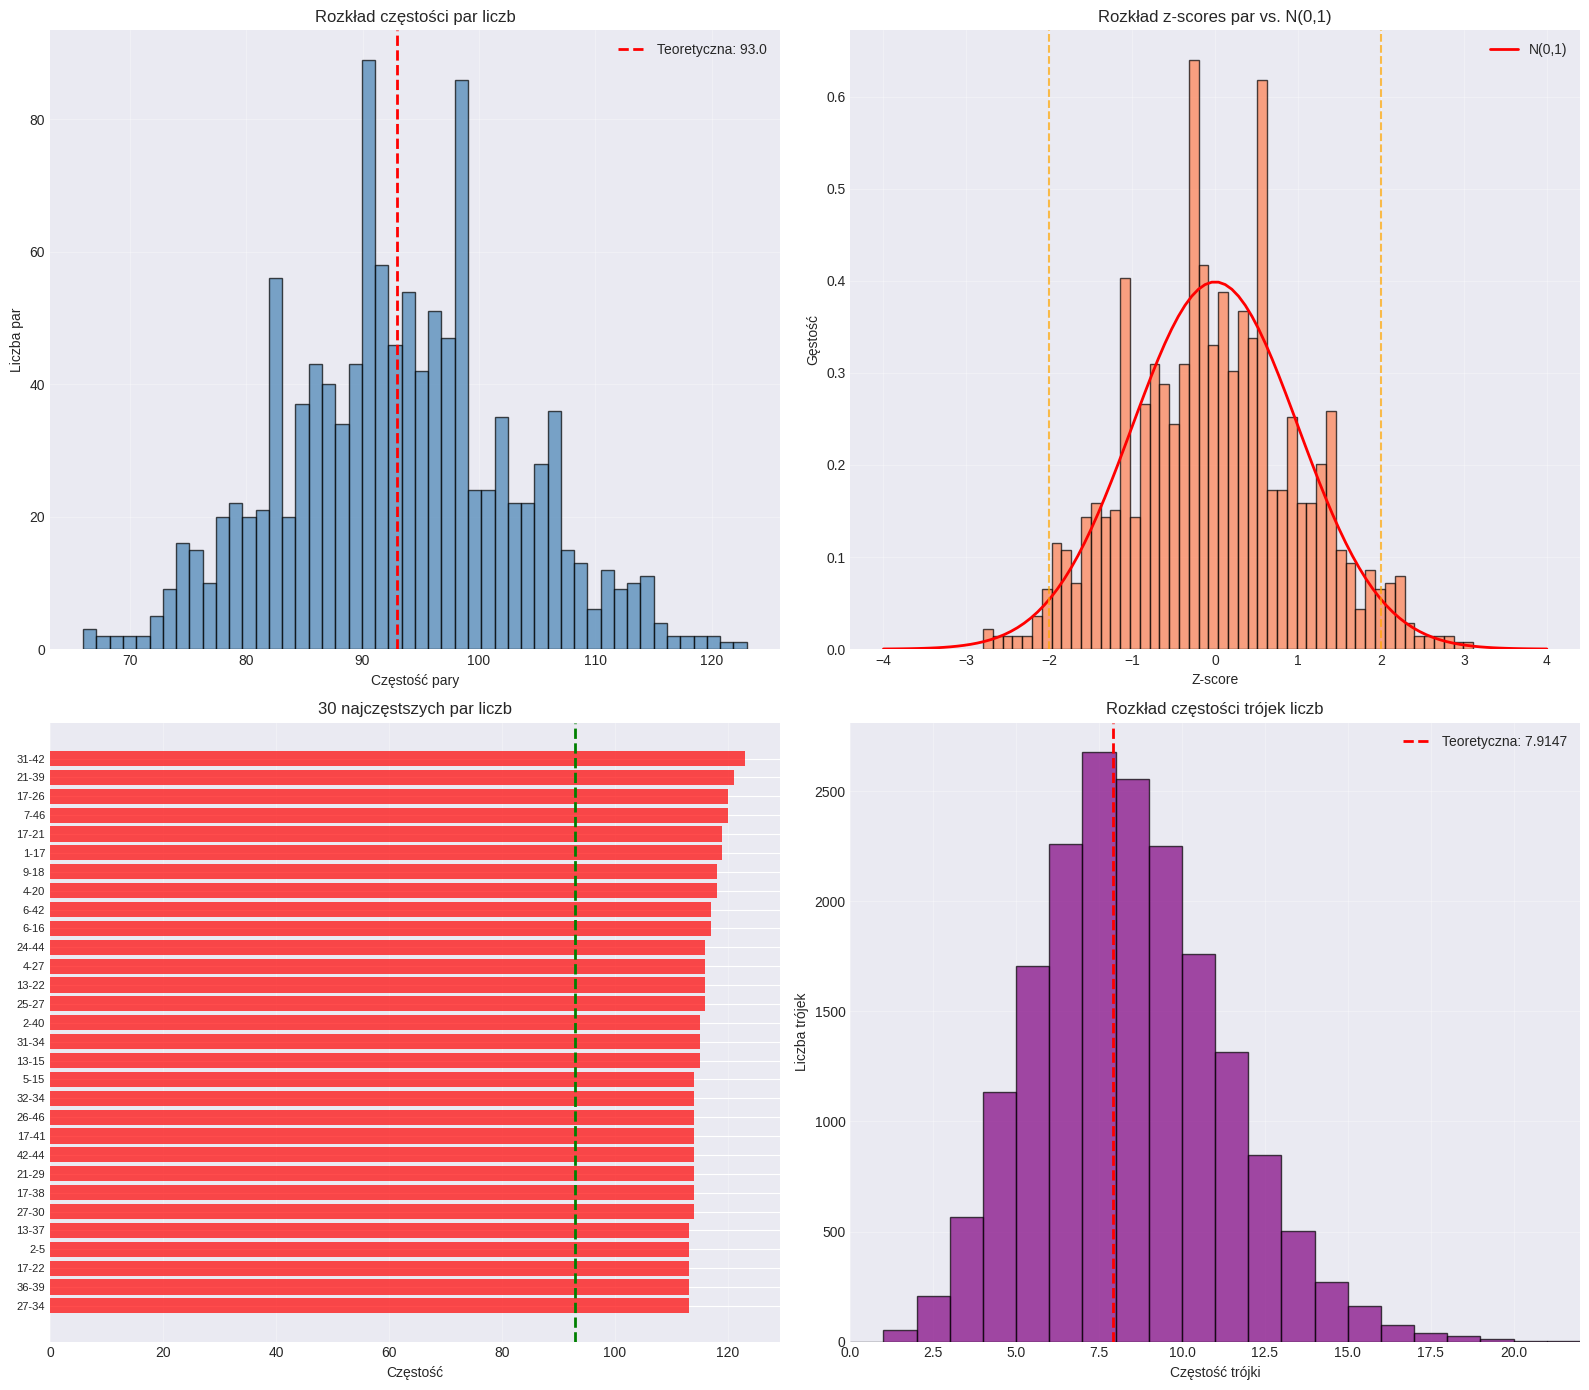

In [29]:
# Wizualizacje

fig, axes = plt.subplots(2, 2, figsize=(16,14))

# Histogram częstości par
ax1 = axes[0,0]
ax1.hist(df_pary['częstość'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(teoretyczna_czestosc_pary, color='red', linestyle='--',  linewidth=2, label=f'Teoretyczna: {teoretyczna_czestosc_pary:.1f}')
ax1.set_xlabel('Częstość pary')
ax1.set_ylabel('Liczba par')
ax1.set_title('Rozkład częstości par liczb')
ax1.legend()
ax1.grid(alpha=0.3)

# z-scores dla par
ax2 = axes[0, 1]
ax2.hist(df_pary['z_score'], bins=50, color='coral', alpha=0.7, edgecolor='black', density=True)
x = np.linspace(-4, 4, 100)
ax2.plot(x, stats.norm.pdf(x, 0, 1), 'r-', linewidth=2, label='N(0,1)')
ax2.axvline(-2, color='orange', linestyle='--', alpha=0.7)
ax2.axvline(2, color='orange', linestyle='--', alpha=0.7)
ax2.set_xlabel('Z-score')
ax2.set_ylabel('Gęstość')
ax2.set_title('Rozkład z-scores par vs. N(0,1)')
ax2.legend()
ax2.grid(alpha=0.3)

# top 30 najczęstszych par
ax3 = axes[1, 0]
top_pary = df_pary.head(30).copy()
top_pary['etykieta'] = top_pary['para'].apply(lambda x: f"{x[0]}-{x[1]}")
colors = ['red' if abs(z) >= 2 else 'steelblue' for z in top_pary['z_score']]
ax3.barh(range(len(top_pary)), top_pary['częstość'], color=colors, alpha=0.7)
ax3.axvline(teoretyczna_czestosc_pary, color='green', linestyle='--', linewidth=2)
ax3.set_yticks(range(len(top_pary)))
ax3.set_yticklabels(top_pary['etykieta'], fontsize=8)
ax3.set_xlabel('Częstość')
ax3.set_title('30 najczęstszych par liczb')
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)

# histogram częstości trójek
ax4 = axes[1, 1]
ax4.hist(df_trojki['częstość'], bins=range(0, df_trojki['częstość'].max()+2),
         color='purple', alpha=0.7, edgecolor='black')
ax4.axvline(teoretyczna_czestosc_trojki, color='red', linestyle='--', linewidth=2,
            label=f'Teoretyczna: {teoretyczna_czestosc_trojki:.4f}')
ax4.set_xlabel('Częstość trójki')
ax4.set_ylabel('Liczba trójek')
ax4.set_title('Rozkład częstości trójek liczb')
ax4.legend()
ax4.grid(alpha=0.3)
ax4.set_xlim(0, max(10, df_trojki['częstość'].max()+1))

plt.tight_layout()
plt.show()


Symuluję 10000 alternatywnych historii (każda po 7291 losowań)...
Twój wynik (Rzeczywistość): 123
Średnia z symulacji (Losowość): 126.01
Typowy zakres w losowym świecie: 117 - 154
Percentyl: 83.71%
Wynik mieści się w normie.


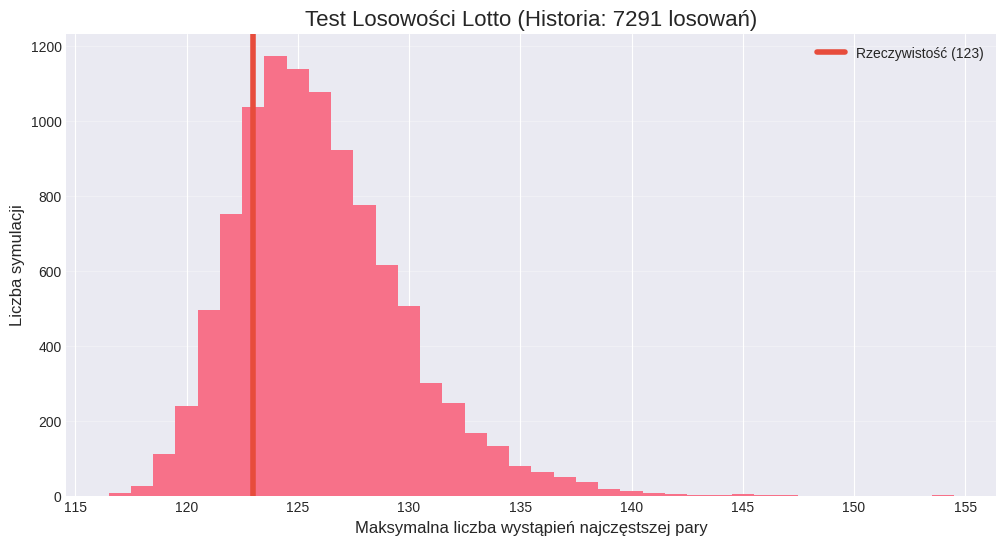

In [30]:
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
from math import comb

n_symulacji = 10000
n_losowan = 7291
rzeczywista_max = 123
n_par = comb(49, 2)

def gpu_draws_fast(n_losowan):
    noise = cp.random.rand(n_losowan, 49, dtype=cp.float32)
    draws = cp.argsort(noise, axis=1)[:, :6]
    draws = cp.sort(draws, axis=1)
    return draws.astype(cp.int32) + 1

wyniki_max = []

print(f"Symuluję {n_symulacji} alternatywnych historii (każda po {n_losowan} losowań)...")

for _ in range(n_symulacji):
    draws = gpu_draws_fast(n_losowan)

    cols_a = []
    cols_b = []
    for a in range(6):
        for b in range(a+1, 6):
            cols_a.append(draws[:, a])
            cols_b.append(draws[:, b])

    A = cp.stack(cols_a)
    B = cp.stack(cols_b)
    idx_A = A - 1
    idx_B = B - 1
    flat_indices = (idx_B * (idx_B - 1)) // 2 + idx_A

    counts = cp.bincount(flat_indices.ravel(), minlength=n_par)


    wyniki_max.append(cp.max(counts).get())

wyniki_max = np.array(wyniki_max)

percentyl = np.mean(wyniki_max >= rzeczywista_max) * 100
srednia_symulacji = wyniki_max.mean()
print(f"Twój wynik (Rzeczywistość): {rzeczywista_max}")
print(f"Średnia z symulacji (Losowość): {srednia_symulacji:.2f}")
print(f"Typowy zakres w losowym świecie: {wyniki_max.min()} - {wyniki_max.max()}")
print(f"Percentyl: {percentyl:.2f}%")

if percentyl > 5 and percentyl < 95:
    print("Wynik mieści się w normie.")
else:
    print("Wynik jest statystycznie nietypowy.")


plt.figure(figsize=(12, 6))

min_val = int(wyniki_max.min())
max_val = int(wyniki_max.max())
plt.hist(wyniki_max, bins=range(min_val, max_val + 2), align='left')

plt.axvline(rzeczywista_max, color='#e74c3c', linestyle='-', linewidth=4, label=f'Rzeczywistość ({rzeczywista_max})')

plt.title(f'Test Losowości Lotto (Historia: {n_losowan} losowań)', fontsize=16)
plt.xlabel('Maksymalna liczba wystąpień najczęstszej pary', fontsize=12)
plt.ylabel('Liczba symulacji', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

In [31]:
# Teoria liczb

def czy_pierwsza(n):
  if n < 2:
    return False
  if n == 2:
    return True
  if n % 2 == 0:
    return False
  for i in range(3, int(sqrt(n)+1), 2):
    if n%i == 0:
      return False
  return True

def fibonacci_50():
  fibs = [1,1]
  while True:
    next_fib = fibs[-1] + fibs[-2]
    if next_fib > 49:
      break
    fibs.append(next_fib)
  return set(fibs)

def liczby_kwadratowe():
  return {i*i for i in range (1, 8)}

def liczby_trojkatne():
  trojkatne = []
  n = 1
  while True:
    t = n * (n + 1) // 2
    if t > 49:
      break
    trojkatne.append(t)
    n += 1
  return set(trojkatne)

liczby_pierwsze = {n for n in range (1, 50) if czy_pierwsza(n)}
liczby_fib = fibonacci_50()
liczby_kwadr = liczby_kwadratowe()
liczby_troj = liczby_trojkatne()
liczby_doskonale = {6, 28} #liczby naturalne będące sumą wszystkich swoich dzielników naturalnych (oprócz samych siebie)

print(f"Liczby pierwsze (1-49): {sorted(liczby_pierwsze)}")
print(f"Liczby Fibonacciego: {sorted(liczby_fib)}")
print(f"Liczby kwadratowe: {sorted(liczby_kwadr)}")
print(f"Liczby trójkątne: {sorted(liczby_troj)}")
print(f"Liczby doskonałe: {sorted(liczby_doskonale)}")

Liczby pierwsze (1-49): [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47]
Liczby Fibonacciego: [1, 2, 3, 5, 8, 13, 21, 34]
Liczby kwadratowe: [1, 4, 9, 16, 25, 36, 49]
Liczby trójkątne: [1, 3, 6, 10, 15, 21, 28, 36, 45]
Liczby doskonałe: [6, 28]


In [32]:
def policz_specjalne(row):
    liczby = set(row[kolumny_liczb].values)
    return pd.Series({
        'liczby_pierwsze': len(liczby & liczby_pierwsze),
        'liczby_fibonacci': len(liczby & liczby_fib),
        'liczby_kwadratowe': len(liczby & liczby_kwadr),
        'liczby_trojkatne': len(liczby & liczby_troj),
        'liczby_doskonale': len(liczby & liczby_doskonale)
    })

df_spec = df.apply(policz_specjalne, axis=1)
for c in df_spec.columns:
    df[c] = df_spec[c]

for col in ['liczby_pierwsze', 'liczby_fibonacci', 'liczby_kwadratowe',
            'liczby_trojkatne', 'liczby_doskonale']:
    print(f"\n{col}:")
    print(df[col].value_counts().sort_index())
    print(f"Średnia: {df[col].mean():.3f}")


liczby_pierwsze:
liczby_pierwsze
0     725
1    2181
2    2525
3    1409
4     408
5      39
6       4
Name: count, dtype: int64
Średnia: 1.825

liczby_fibonacci:
liczby_fibonacci
0    2248
1    3184
2    1518
3     316
4      24
5       1
Name: count, dtype: int64
Średnia: 0.997

liczby_kwadratowe:
liczby_kwadratowe
0    2671
1    3177
2    1233
3     198
4      12
Name: count, dtype: int64
Średnia: 0.862

liczby_trojkatne:
liczby_trojkatne
0    1923
1    3091
2    1791
3     419
4      65
5       2
Name: count, dtype: int64
Średnia: 1.125

liczby_doskonale:
liczby_doskonale
0    5552
1    1635
2     104
Name: count, dtype: int64
Średnia: 0.253


In [33]:
# Arytmetyka i algebra

from functools import reduce
from math import gcd, lcm

def oblicz_nwd(liczby):
  return reduce(gcd, liczby)

def oblicz_nww(liczby):
  return reduce(lcm, liczby)

def srednia_geom(liczby):
  product = np.prod(liczby)
  return product ** (1/len(liczby))

def srednia_harm(liczby):
  return len(liczby) / sum(1/x for x in liczby)

df['nwd'] = df[kolumny_liczb].apply(lambda row: oblicz_nwd(row.values), axis=1)
df['nww'] = df[kolumny_liczb].apply(lambda row: oblicz_nww(row.values), axis=1)
df['srednia_arytm'] = df[kolumny_liczb].mean(axis=1)
df['srednia_geom'] = df[kolumny_liczb].apply(lambda row: srednia_geom(row.values), axis=1)
df['srednia_harm'] = df[kolumny_liczb].apply(lambda row: srednia_harm(row.values), axis=1)
df['wariancja'] = df[kolumny_liczb].var(axis=1)
df['std_dev'] = df[kolumny_liczb].std(axis=1)

print(f"NWD - rozkład:")
print(df['nwd'].value_counts().sort_index().head(10))
print(f"\nNajczęstszy NWD: {df['nwd'].mode()[0]}")

print(f"\nŚrednia arytmetyczna: {df['srednia_arytm'].mean():.2f}")
print(f"Średnia geometryczna: {df['srednia_geom'].mean():.2f}")
print(f"Średnia harmoniczna: {df['srednia_harm'].mean():.2f}")

print(f"\nNWW - statystyki:")
print(f"Min: {df['nww'].min()}")
print(f"Max: {df['nww'].max()}")
print(f"Mediana: {df['nww'].median():.0f}")

NWD - rozkład:
nwd
1    7198
2      91
3       2
Name: count, dtype: int64

Najczęstszy NWD: 1

Średnia arytmetyczna: 24.86
Średnia geometryczna: 20.05
Średnia harmoniczna: 15.13

NWW - statystyki:
Min: 72
Max: 2177523348
Mediana: 435708


In [37]:
# Wzorce cyfrowe

def suma_cyfr(n):
  return sum(int(d) for d in str(n))

def digit_root(n):
  while n > 9:
    n = suma_cyfr(n)
  return n

# Cyfry jednostkowe i dziesiątek
df['cyfry_jednostkowe'] = df[kolumny_liczb].applymap(lambda x: x % 10).apply(
    lambda row: tuple(sorted(row)), axis=1)

# Suma cyfr wszystkich liczb
df['suma_wszystkich_cyfr'] = df[kolumny_liczb].map(suma_cyfr).sum(axis=1)
df['digit_root_sumy'] = df['suma_wszystkich_cyfr'].apply(digit_root)

# Liczby z powtarzającymi się cyframi
palindromy = {11, 22, 33, 44}
df['liczba_palindromow'] = df[kolumny_liczb].applymap(
    lambda x: x in palindromy).sum(axis=1)

print(f"\nLiczba palindromów (11, 22, 33, 44) w zestawie:")
print(df['liczba_palindromow'].value_counts().sort_index())

print(f"\nSuma cyfr - rozkład digit root:")
print(df['digit_root_sumy'].value_counts().sort_index())

# Rozkład cyfr jednostkowych
from itertools import chain
wszystkie_cyfry_jedn = list(chain.from_iterable(
    df[kolumny_liczb].map(lambda x: x % 10).values))
cyfry_count = Counter(wszystkie_cyfry_jedn)

print(f"\nRozkład cyfr jednostkowych (0-9):")
for cyfra in range(10):
    print(f"  {cyfra}: {cyfry_count[cyfra]}")



Liczba palindromów (11, 22, 33, 44) w zestawie:
liczba_palindromow
0    4303
1    2516
2     440
3      31
4       1
Name: count, dtype: int64

Suma cyfr - rozkład digit root:
digit_root_sumy
1    811
2    833
3    816
4    824
5    788
6    813
7    806
8    813
9    787
Name: count, dtype: int64

Rozkład cyfr jednostkowych (0-9):
  0: 3547
  1: 4517
  2: 4448
  3: 4346
  4: 4551
  5: 4486
  6: 4500
  7: 4510
  8: 4431
  9: 4410


/tmp/ipython-input-1972099821.py:12: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.

/tmp/ipython-input-1972099821.py:21: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



In [38]:
# Różnice między liczbami

def oblicz_gaps(row):
    liczby = sorted(row[kolumny_liczb].values)
    gaps = [liczby[i+1] - liczby[i] for i in range(5)]
    return pd.Series({
        'gap_srednia': np.mean(gaps),
        'gap_max': max(gaps),
        'gap_min': min(gaps),
        'gap_std': np.std(gaps),
        'gap_roznych': len(set(gaps))
    })

df_gaps = df.apply(oblicz_gaps, axis=1)
df = pd.concat([df, df_gaps], axis=1)

print("--- STATYSTYKI GAPS ---")
print(f"Średni gap: {df['gap_srednia'].mean():.2f}")
print(f"Średni max gap: {df['gap_max'].mean():.2f}")
print(f"Średni min gap: {df['gap_min'].mean():.2f}")

print(f"\nRozkład minimalnego gap:")
print(df['gap_min'].value_counts().sort_index())

print(f"\nRozkład maksymalnego gap:")
print(df['gap_max'].value_counts().sort_index().head(20))

--- STATYSTYKI GAPS ---
Średni gap: 7.12
Średni max gap: 15.55
Średni min gap: 1.85

Rozkład minimalnego gap:
gap_min
1.0    3638
2.0    2033
3.0     965
4.0     442
5.0     144
6.0      62
7.0       5
8.0       2
Name: count, dtype: int64

Rozkład maksymalnego gap:
gap_max
2.0       1
3.0       6
4.0      16
5.0      42
6.0      85
7.0     134
8.0     197
9.0     280
10.0    407
11.0    444
12.0    555
13.0    606
14.0    609
15.0    557
16.0    569
17.0    498
18.0    418
19.0    349
20.0    321
21.0    258
Name: count, dtype: int64


In [42]:
# Symetrie i odbicia

def symetria_analiza(row):
    liczby = row[kolumny_liczb].values

    # Pary symetryczne: (x, 50-x)
    pary_sym = 0
    for x in liczby:
        if (50 - x) in liczby and x != 25:
            pary_sym += 1
    pary_sym = pary_sym // 2  # każda para liczymy raz

    avg_dist = np.mean([abs(x - 25) for x in liczby])

    balance = sum(x - 25 for x in liczby)

    return pd.Series({
        'pary_symetryczne': pary_sym,
        'avg_dystans_od_25': avg_dist,
        'balance_index': balance
    })

df_sym = df.apply(symetria_analiza, axis=1)

for c in df_sym.columns:
    df[c] = df_sym[c]

print(f"\nPary symetryczne (np. 10 i 40):")
print(df['pary_symetryczne'].value_counts().sort_index())

print(f"\nBalance index (suma odchyleń od 25):")
print(f"Średnia: {df['balance_index'].mean():.2f}")
print(f"Std: {df['balance_index'].std():.2f}")
print(f"Min: {df['balance_index'].min()}")
print(f"Max: {df['balance_index'].max()}")


Pary symetryczne (np. 10 i 40):
pary_symetryczne
0.0    5203
1.0    1951
2.0     136
3.0       1
Name: count, dtype: int64

Balance index (suma odchyleń od 25):
Średnia: -0.83
Std: 32.49
Min: -115.0
Max: 115.0


In [46]:
# Podzielności i reszty

def dzielnosc_analiza(row):
    liczby = row[kolumny_liczb].values
    suma = row['suma_wszystkich_cyfr']

    return pd.Series({
        'podzielne_przez_3': sum(x % 3 == 0 for x in liczby),
        'podzielne_przez_5': sum(x % 5 == 0 for x in liczby),
        'podzielne_przez_7': sum(x % 7 == 0 for x in liczby),
        'suma_mod_3': suma % 3,
        'suma_mod_5': suma % 5,
        'suma_mod_7': suma % 7,
        'suma_mod_10': suma % 10
    })

df_dziel = df.apply(dzielnosc_analiza, axis=1)

for c in df_dziel.columns:
    df[c] = df_dziel[c]

print(f"\nLiczby podzielne przez 3:")
print(df['podzielne_przez_3'].value_counts().sort_index())

print(f"\nLiczby podzielne przez 5:")
print(df['podzielne_przez_5'].value_counts().sort_index())

print(f"\nSuma modulo 10 (cyfra końcowa sumy):")
print(df['suma_mod_10'].value_counts().sort_index())



Liczby podzielne przez 3:
podzielne_przez_3
0     591
1    1932
2    2583
3    1590
4     517
5      76
6       2
Name: count, dtype: int64

Liczby podzielne przez 5:
podzielne_przez_5
0    1997
1    3084
2    1736
3     421
4      51
5       2
Name: count, dtype: int64

Suma modulo 10 (cyfra końcowa sumy):
suma_mod_10
0    708
1    734
2    712
3    766
4    706
5    715
6    770
7    731
8    719
9    730
Name: count, dtype: int64


In [47]:
# Statystyki rozkładu

from scipy.stats import skew, kurtosis

def stats_rozklad(row):
    liczby = row[kolumny_liczb].values.astype(float)
    return pd.Series({
        'mediana': np.median(liczby),
        'skewness': skew(liczby),
        'kurtosis': kurtosis(liczby),
        'iqr': np.percentile(liczby, 75) - np.percentile(liczby, 25)
    })

df_stats = df.apply(stats_rozklad, axis=1)
df = pd.concat([df, df_stats], axis=1)

print(f"Średnia mediana: {df['mediana'].mean():.2f}")
print(f"Średnia skewness: {df['skewness'].mean():.4f}")
print(f"Średnia kurtosis: {df['kurtosis'].mean():.4f}")
print(f"Średni IQR: {df['iqr'].mean():.2f}")


Średnia mediana: 24.86
Średnia skewness: 0.0004
Średnia kurtosis: -1.0657
Średni IQR: 17.70


In [51]:
# Właściwości bitowe

def bitowe_analiza(row):
    liczby = row[kolumny_liczb].values

    popcount_total = sum(bin(x).count('1') for x in liczby)

    xor_all = reduce(lambda a, b: a ^ b, liczby)

    and_all = reduce(lambda a, b: a & b, liczby)

    or_all = reduce(lambda a, b: a | b, liczby)

    return pd.Series({
        'popcount_total': popcount_total,
        'xor_all': xor_all,
        'and_all': and_all,
        'or_all': or_all
    })

df_bit = df.apply(bitowe_analiza, axis=1)

for c in df_bit.columns:
    df[c] = df_bit[c]

print(f"Średni popcount: {df['popcount_total'].mean():.2f}")
print(f"\nXOR wszystkich liczb - rozkład:")
print(df['xor_all'].value_counts().sort_index().head(10))
print(f"\nOR wszystkich liczb:")
print(df['or_all'].value_counts().sort_index().head(20))

print(f"\nAND wszystkich liczb:")
print(df['and_all'].value_counts().sort_index())

Średni popcount: 16.26

XOR wszystkich liczb - rozkład:
xor_all
0    116
1    110
2    126
3    110
4     99
5    119
6    124
7    105
8    142
9     89
Name: count, dtype: int64

OR wszystkich liczb:
or_all
15       2
23       3
27       1
29       5
30       3
31     382
39       1
43       2
45       2
46       2
47     361
54       1
55     104
57       2
58       1
59      90
61      82
62      84
63    6163
Name: count, dtype: int64

AND wszystkich liczb:
and_all
0     6970
1       96
2       69
4       64
6        2
8       64
9        2
16       9
32      15
Name: count, dtype: int64


In [52]:
# Entropia

def oblicz_entropie(row):
    liczby = row[kolumny_liczb].values
    probs = liczby / liczby.sum()
    entropy = -sum(p * np.log2(p) for p in probs if p > 0)
    return entropy

df['entropia'] = df.apply(oblicz_entropie, axis=1)

print(f"Średnia entropia: {df['entropia'].mean():.4f}")
print(f"Min entropia: {df['entropia'].min():.4f}")
print(f"Max entropia: {df['entropia'].max():.4f}")

Średnia entropia: 2.3364
Min entropia: 1.6593
Max entropia: 2.5811


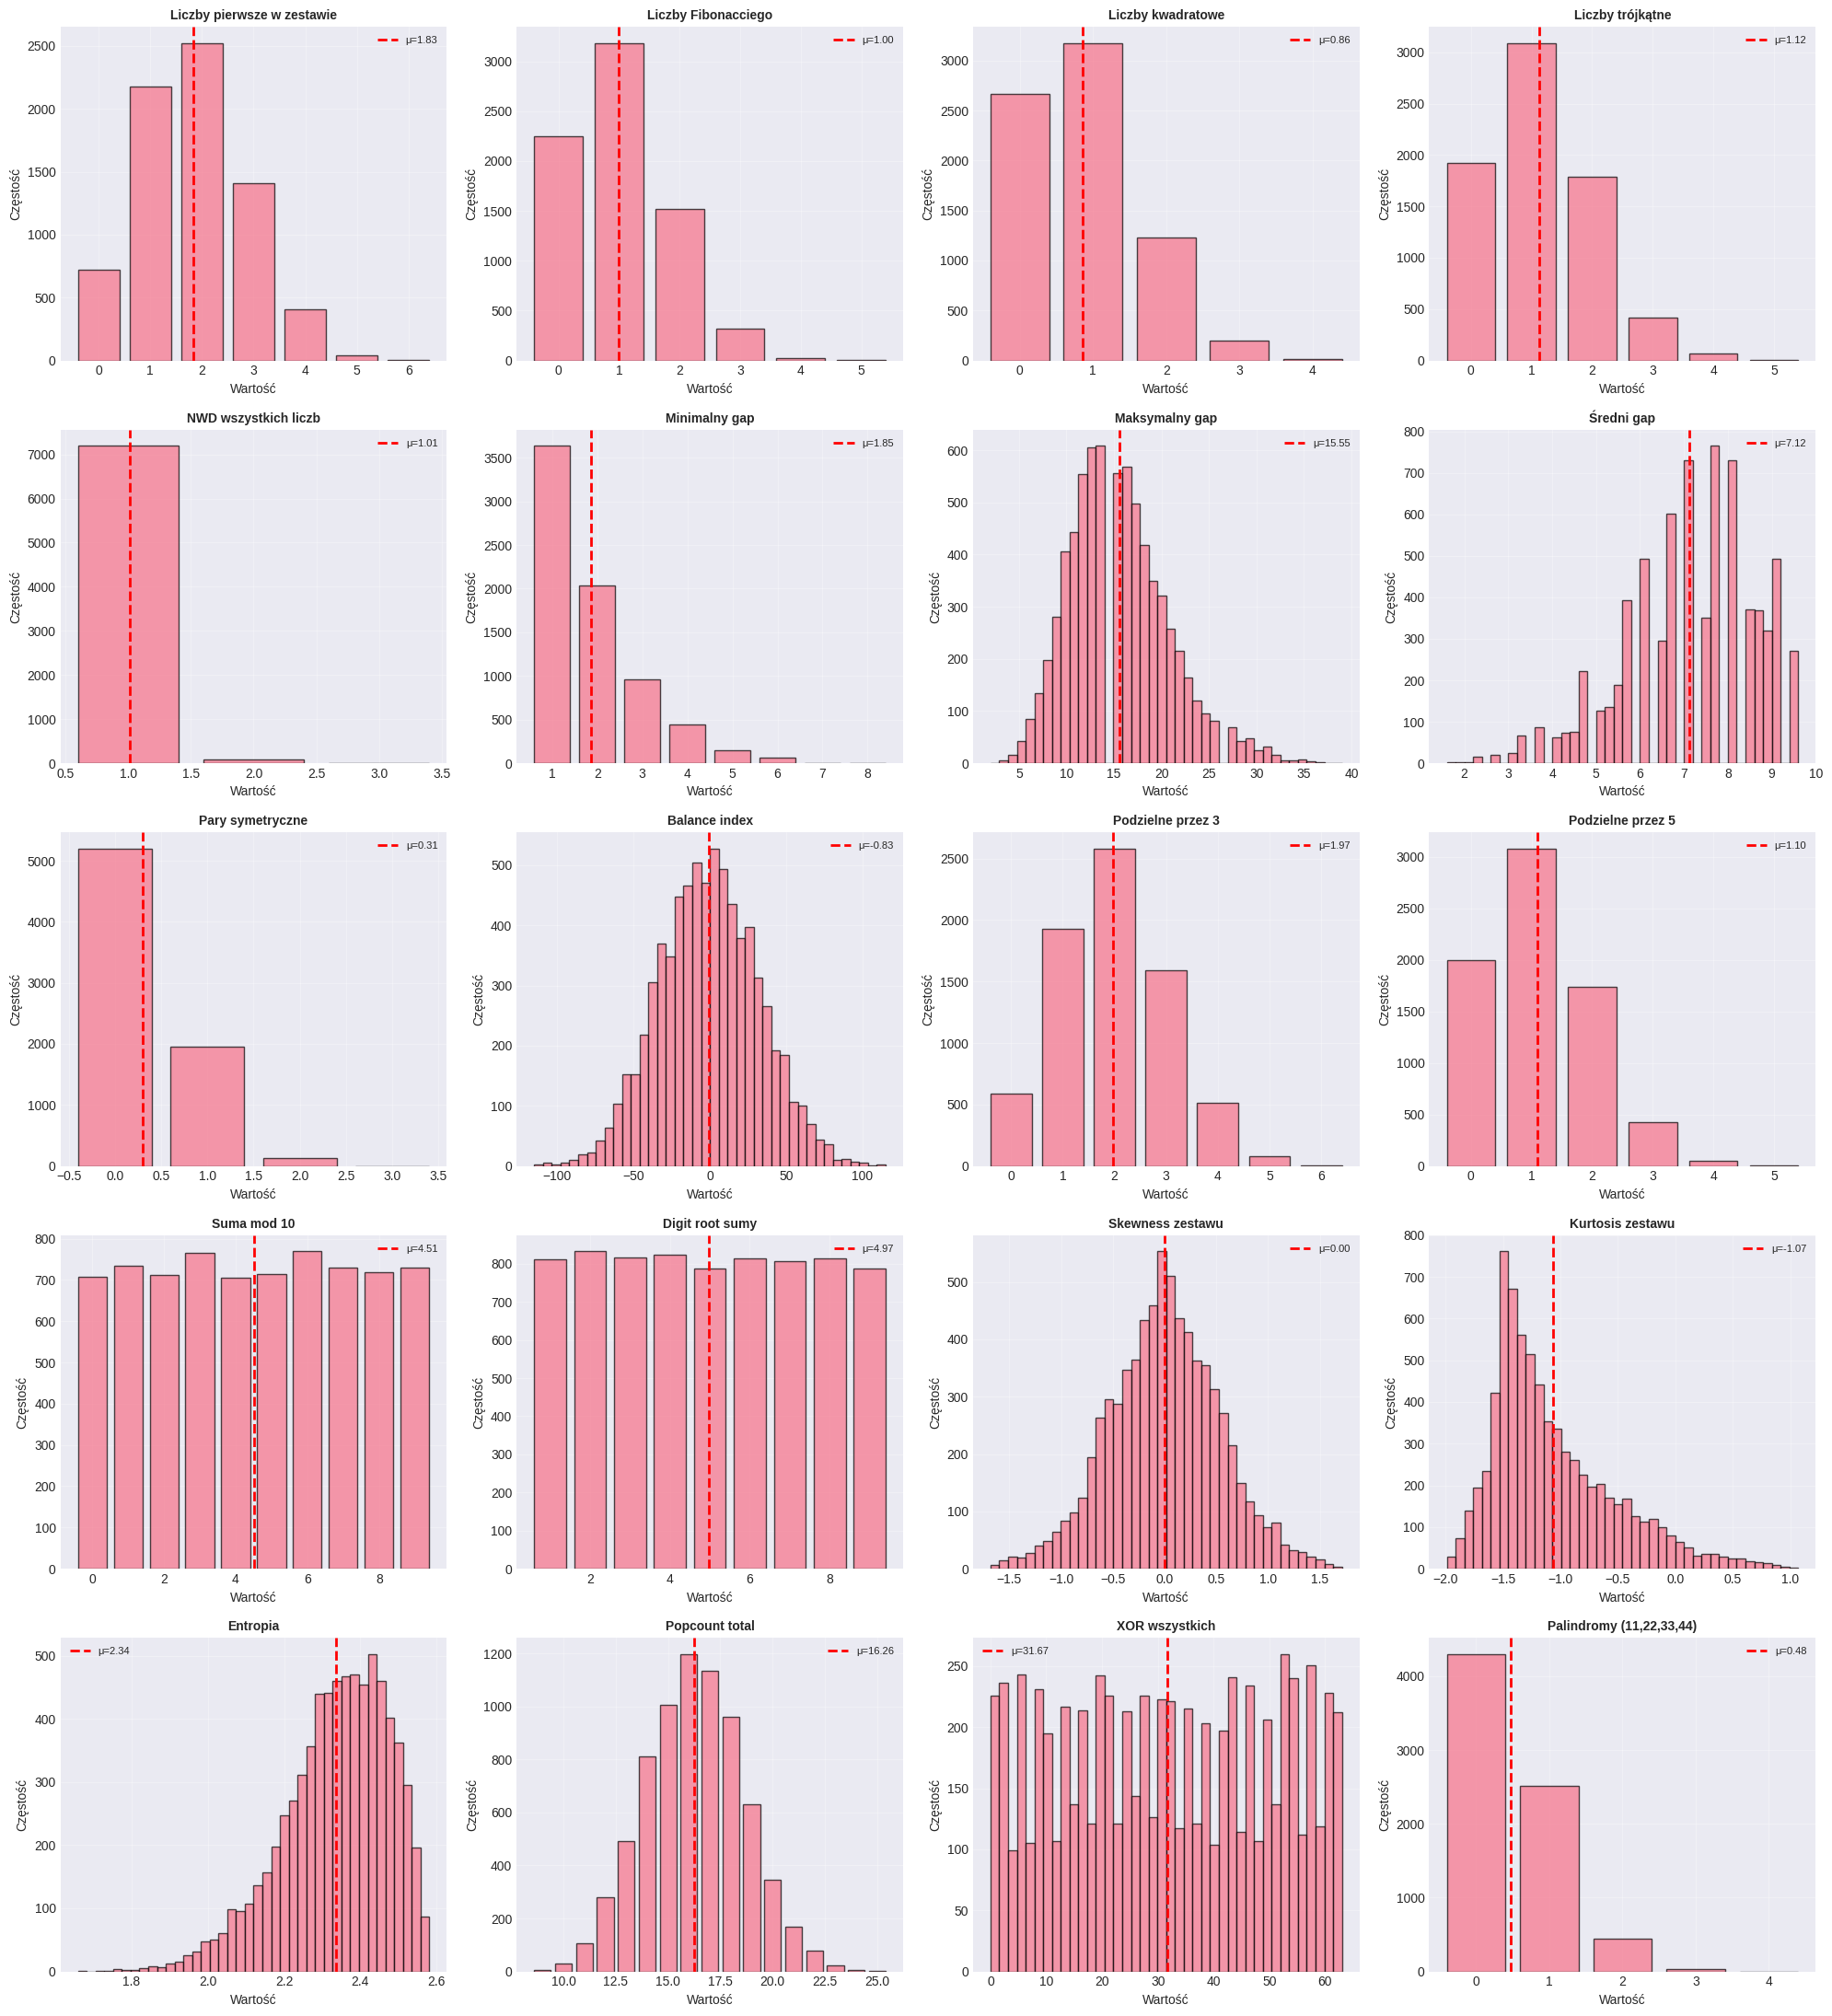

In [53]:
fig, axes = plt.subplots(5, 4, figsize=(20, 22))
axes = axes.flatten()

# Lista właściwości do wizualizacji
wlasciwosci_viz = [
    ('liczby_pierwsze', 'Liczby pierwsze w zestawie'),
    ('liczby_fibonacci', 'Liczby Fibonacciego'),
    ('liczby_kwadratowe', 'Liczby kwadratowe'),
    ('liczby_trojkatne', 'Liczby trójkątne'),
    ('nwd', 'NWD wszystkich liczb'),
    ('gap_min', 'Minimalny gap'),
    ('gap_max', 'Maksymalny gap'),
    ('gap_srednia', 'Średni gap'),
    ('pary_symetryczne', 'Pary symetryczne'),
    ('balance_index', 'Balance index'),
    ('podzielne_przez_3', 'Podzielne przez 3'),
    ('podzielne_przez_5', 'Podzielne przez 5'),
    ('suma_mod_10', 'Suma mod 10'),
    ('digit_root_sumy', 'Digit root sumy'),
    ('skewness', 'Skewness zestawu'),
    ('kurtosis', 'Kurtosis zestawu'),
    ('entropia', 'Entropia'),
    ('popcount_total', 'Popcount total'),
    ('xor_all', 'XOR wszystkich'),
    ('liczba_palindromow', 'Palindromy (11,22,33,44)')
]

for idx, (col, title) in enumerate(wlasciwosci_viz):
    ax = axes[idx]

    data = df[col].dropna()

    # Histogram
    if data.nunique() < 30:  # Dyskretna
        counts = data.value_counts().sort_index()
        ax.bar(counts.index, counts.values, alpha=0.7, edgecolor='black')
        ax.set_xlabel('Wartość')
    else:  # Ciągła
        ax.hist(data, bins=40, alpha=0.7, edgecolor='black')
        ax.set_xlabel('Wartość')

    ax.set_ylabel('Częstość')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3)

    # Dodaj statystyki
    mean_val = data.mean()
    std_val = data.std()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2,
               label=f'μ={mean_val:.2f}')
    ax.legend(fontsize=8)

plt.tight_layout()

In [55]:
print("\nTEST 1: LICZBY PIERWSZE")
# Prawdopodobieństwo wylosowania liczby pierwszej = 15/49
p_pierwsza = 15 / 49
teoretyczny_rozklad_pierw = {}
for k in range(7):
    prob = stats.binom.pmf(k, 6, p_pierwsza)
    teoretyczny_rozklad_pierw[k] = prob * len(df)

obserwowane_pierw = [sum(df['liczby_pierwsze'] == k) for k in range(7)]
oczekiwane_pierw = [teoretyczny_rozklad_pierw[k] for k in range(7)]

chi2_pierw, p_pierw = stats.chisquare(obserwowane_pierw, oczekiwane_pierw)
print(f"Test chi-kwadrat: χ² = {chi2_pierw:.4f}, p = {p_pierw:.6f}")
if p_pierw > 0.05:
    print("Rozkład zgodny z teorią")
else:
    print("Rozkład różni się od teorii")

print("\nTEST 2: MINIMALNY GAP")
print("Rozkład minimalnego gap:")
print(df['gap_min'].value_counts().sort_index())
print(f"Średni gap_min: {df['gap_min'].mean():.3f}")
print("Interpretacja: ~50% losowań ma gap=1 (liczby kolejne)")

print("\nTEST 3: BALANCE INDEX (symetria)")
t_bal, p_bal = stats.ttest_1samp(df['balance_index'], 0)
print(f"Test t (H0: średnia = 0): t = {t_bal:.4f}, p = {p_bal:.6f}")
if p_bal > 0.05:
    print("Balance index jest symetryczny wokół zera")
else:
    print("Balance index różni się od zera")

print("\nTEST 4: SUMA MODULO 10")
obserwowane_mod10 = [sum(df['suma_mod_10'] == k) for k in range(10)]
oczekiwane_mod10 = [len(df) / 10] * 10

chi2_mod10, p_mod10 = stats.chisquare(obserwowane_mod10, oczekiwane_mod10)
print(f"Test chi-kwadrat: χ² = {chi2_mod10:.4f}, p = {p_mod10:.6f}")
if p_mod10 > 0.05:
    print("Rozkład równomierny")
else:
    print("Rozkład nierównomierny")

print("\nTEST 5: SKEWNESS (skośność rozkładu)")
t_skew, p_skew = stats.ttest_1samp(df['skewness'], 0)
print(f"Test t (H0: średnia = 0): t = {t_skew:.4f}, p = {p_skew:.6f}")
print(f"Średnia skewness: {df['skewness'].mean():.6f}")
if p_skew > 0.05:
    print("Rozkład symetryczny")
else:
    print("Rozkład asymetryczny")


TEST 1: LICZBY PIERWSZE
Test chi-kwadrat: χ² = 48.7953, p = 0.000000
Rozkład różni się od teorii

TEST 2: MINIMALNY GAP
Rozkład minimalnego gap:
gap_min
1.0    3638
2.0    2033
3.0     965
4.0     442
5.0     144
6.0      62
7.0       5
8.0       2
Name: count, dtype: int64
Średni gap_min: 1.853
Interpretacja: ~50% losowań ma gap=1 (liczby kolejne)

TEST 3: BALANCE INDEX (symetria)
Test t (H0: średnia = 0): t = -2.1796, p = 0.029323
Balance index różni się od zera

TEST 4: SUMA MODULO 10
Test chi-kwadrat: χ² = 6.3570, p = 0.703723
Rozkład równomierny

TEST 5: SKEWNESS (skośność rozkładu)
Test t (H0: średnia = 0): t = 0.0575, p = 0.954135
Średnia skewness: 0.000360
Rozkład symetryczny



Silne korelacje (|r| > 0.3):
  gap_max <-> gap_srednia: r = 0.653
  gap_srednia <-> entropia: r = -0.619
  balance_index <-> entropia: r = 0.613
  balance_index <-> skewness: r = -0.558
  liczby_fibonacci <-> entropia: r = -0.518
  gap_max <-> entropia: r = -0.509
  liczby_fibonacci <-> balance_index: r = -0.442
  liczby_pierwsze <-> podzielne_przez_3: r = -0.367
  skewness <-> entropia: r = -0.327


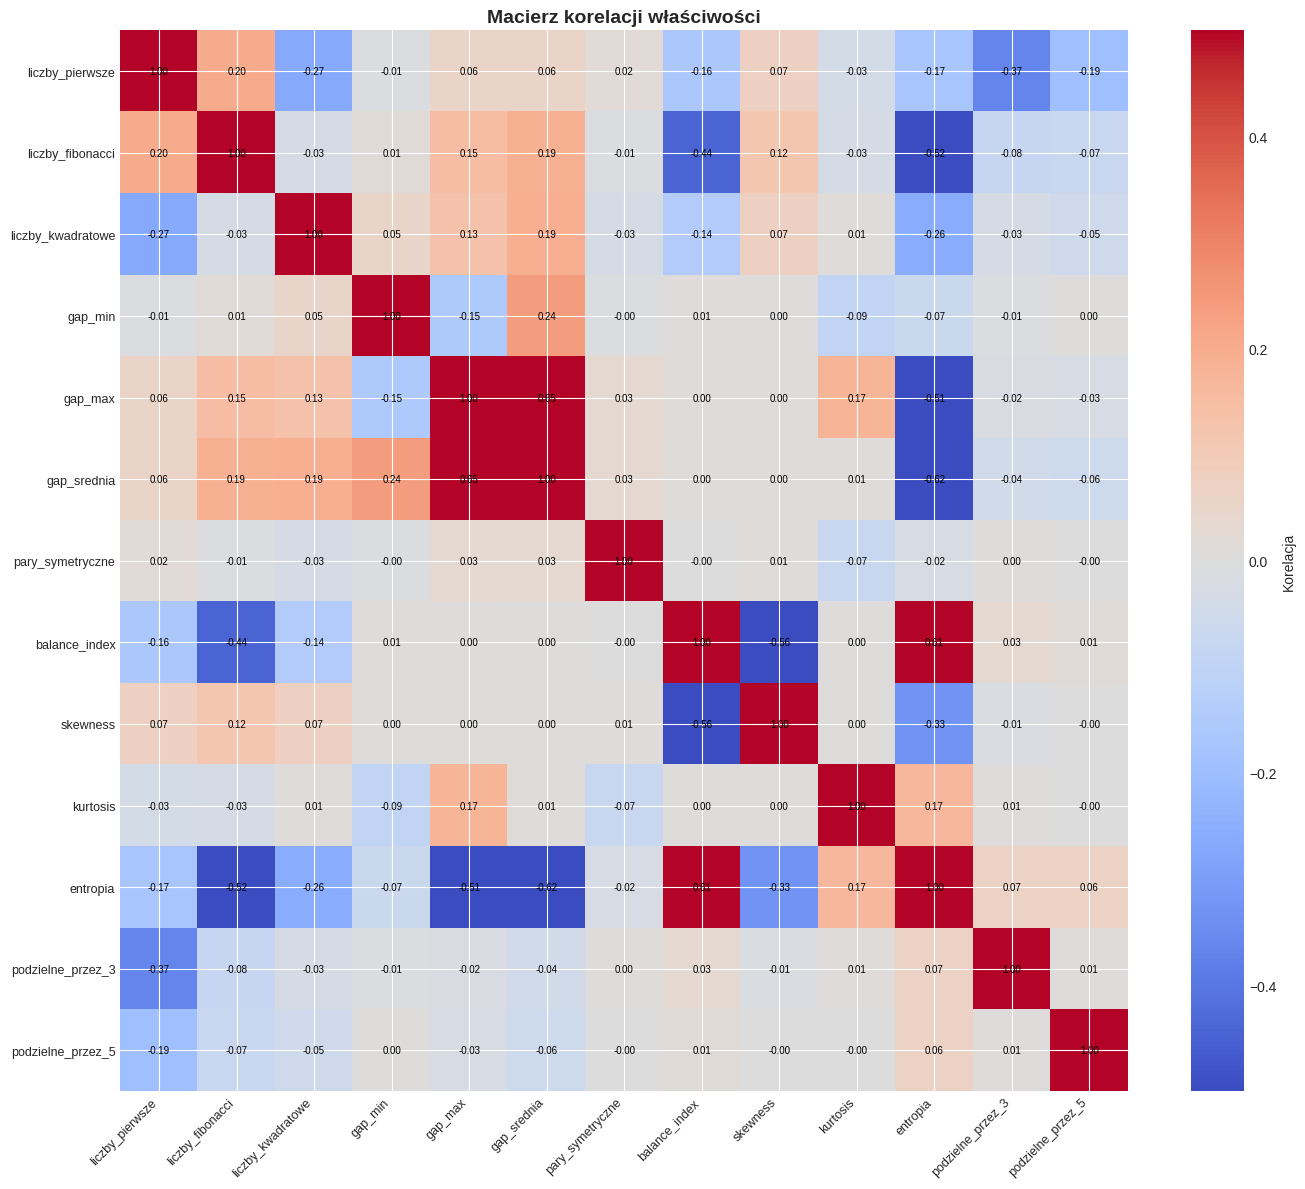

In [56]:
wlasciwosci_korel = [
    'liczby_pierwsze', 'liczby_fibonacci', 'liczby_kwadratowe',
    'gap_min', 'gap_max', 'gap_srednia', 'pary_symetryczne',
    'balance_index', 'skewness', 'kurtosis', 'entropia',
    'podzielne_przez_3', 'podzielne_przez_5'
]

korelacje = df[wlasciwosci_korel].corr()

# Znajdź najbardziej skorelowane pary (oprócz diagonali)
strong_corr = []
for i in range(len(korelacje)):
    for j in range(i+1, len(korelacje)):
        corr_val = korelacje.iloc[i, j]
        if abs(corr_val) > 0.3:
            strong_corr.append((korelacje.index[i], korelacje.columns[j], corr_val))

if strong_corr:
    print("\nSilne korelacje (|r| > 0.3):")
    for prop1, prop2, corr in sorted(strong_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {prop1} <-> {prop2}: r = {corr:.3f}")
else:
    print("\nBrak silnych korelacji - właściwości są niezależne!")

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(korelacje, cmap='coolwarm', vmin=-0.5, vmax=0.5, aspect='auto')
ax.set_xticks(range(len(wlasciwosci_korel)))
ax.set_yticks(range(len(wlasciwosci_korel)))
ax.set_xticklabels(wlasciwosci_korel, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(wlasciwosci_korel, fontsize=9)
ax.set_title('Macierz korelacji właściwości', fontsize=14, fontweight='bold')

for i in range(len(wlasciwosci_korel)):
    for j in range(len(wlasciwosci_korel)):
        text = ax.text(j, i, f'{korelacje.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=7)

plt.colorbar(im, ax=ax, label='Korelacja')
plt.tight_layout()

In [59]:
# Analiza anomalii - ekstremalne losowania

print("\nLosowania z najwyższą entropią")
top_entropy = df.nlargest(5, 'entropia')[['nr_losowania', 'data', 'l1', 'l2', 'l3', 'l4', 'l5', 'l6', 'entropia']]
print(top_entropy.to_string(index=False))

print("\nLosowania z najniższą entropią")
low_entropy = df.nsmallest(5, 'entropia')[['nr_losowania', 'data', 'l1', 'l2', 'l3', 'l4', 'l5', 'l6', 'entropia']]
print(low_entropy.to_string(index=False))

print("\nLosowania z największym balance index")
max_balance = df.nlargest(5, 'balance_index')[['nr_losowania', 'data', 'l1', 'l2', 'l3', 'l4', 'l5', 'l6', 'balance_index']]
print(max_balance.to_string(index=False))

print("\nLosowania tylko z liczb pierwszych")
same_pierwsze = df[df['liczby_pierwsze'] == 6]
if len(same_pierwsze) > 0:
    print(same_pierwsze[['nr_losowania', 'data', 'l1', 'l2', 'l3', 'l4', 'l5', 'l6']].to_string(index=False))
else:
    print("Brak takich losowań")

print("\nLosowania z NWD > 1")
nwd_duze = df[df['nwd'] > 1].nlargest(10, 'nwd')[['nr_losowania', 'data', 'l1', 'l2', 'l3', 'l4', 'l5', 'l6', 'nwd']]
print(nwd_duze.to_string(index=False))



Losowania z najwyższą entropią
nr_losowania       data  l1  l2  l3  l4  l5  l6  entropia
        4424 2007-08-29  39  41  43  45  47  48  2.581136
        5696 2015-10-15  40  41  42  46  47  49  2.580851
        0165 1960-04-10  34  35  38  39  40  44  2.579652
        3252 1996-06-05  30  31  32  33  37  38  2.579296
        0079 1958-08-17  34  35  37  38  39  45  2.578795

Losowania z najniższą entropią
nr_losowania       data  l1  l2  l3  l4  l5  l6  entropia
        5361 2013-08-24   1   2   4   6  20  47  1.659253
        0222 1961-05-14   1   2   4   9  40  48  1.705395
        0855 1972-12-10   1   2   3   8  33  37  1.749821
        0131 1959-08-16   1   2   4   5  23  36  1.758636
        5609 2015-03-26   2   3   5   6  18  48  1.759855

Losowania z największym balance index
nr_losowania       data  l1  l2  l3  l4  l5  l6  balance_index
        5696 2015-10-15  40  41  42  46  47  49          115.0
        4424 2007-08-29  39  41  43  45  47  48          113.0
        6431

In [62]:
# Hot & cold numbers
def hot_cold_analysis(ostatnie_n=100):
    ostatnie_losowan = df.tail(ostatnie_n)
    wszystkie_liczby = []

    for _, row in ostatnie_losowan.iterrows():
        wszystkie_liczby.extend(row[kolumny_liczb].values)

    counter = Counter(wszystkie_liczby)

    hot = counter.most_common(10)
    cold = [(num, counter.get(num, 0)) for num in range(1, 50)]
    cold = sorted(cold, key=lambda x: x[1])[:10]

    return hot, cold

hot_100, cold_100 = hot_cold_analysis(100)
print("\nHOT numbers (najczęstsze):")
for num, count in hot_100:
    print(f"  {num:2d}: {count} razy")

print("\nCOLD numbers (najrzadsze):")
for num, count in cold_100:
    print(f"  {num:2d}: {count} razy")

print("\nPorównanie okien czasowych")
okienka = [50, 100, 200, 500]

for n in okienka:
    if n <= len(df):
        hot, cold = hot_cold_analysis(n)
        print(f"\nOstatnie {n} losowań:")
        print(f"Najczęstsza liczba: {hot[0][0]} ({hot[0][1]} razy)")
        print(f"Najrzadsza liczba: {cold[0][0]} ({cold[0][1]} razy)")


HOT numbers (najczęstsze):
  30: 19 razy
  46: 18 razy
  32: 18 razy
  36: 17 razy
  45: 17 razy
  43: 17 razy
  39: 16 razy
  20: 15 razy
  42: 15 razy
   5: 15 razy

COLD numbers (najrzadsze):
  48: 3 razy
  16: 5 razy
   1: 6 razy
   4: 6 razy
  29: 6 razy
  41: 7 razy
  40: 8 razy
   2: 9 razy
   8: 9 razy
   9: 10 razy

Porównanie okien czasowych

Ostatnie 50 losowań:
Najczęstsza liczba: 27 (11 razy)
Najrzadsza liczba: 41 (1 razy)

Ostatnie 100 losowań:
Najczęstsza liczba: 30 (19 razy)
Najrzadsza liczba: 48 (3 razy)

Ostatnie 200 losowań:
Najczęstsza liczba: 20 (39 razy)
Najrzadsza liczba: 16 (14 razy)

Ostatnie 500 losowań:
Najczęstsza liczba: 2 (80 razy)
Najrzadsza liczba: 29 (47 razy)


In [63]:
# Overdue numbers

def oblicz_overdue():
    ostatnie_wystapienie = {}

    for idx in range(len(df)-1, -1, -1):
        row = df.iloc[idx]
        liczby = set(row[kolumny_liczb].values)

        for num in range(1, 50):
            if num not in ostatnie_wystapienie and num in liczby:
                ostatnie_wystapienie[num] = len(df) - 1 - idx

    for num in range(1, 50):
        if num not in ostatnie_wystapienie:
            ostatnie_wystapienie[num] = len(df)

    return ostatnie_wystapienie

overdue = oblicz_overdue()
overdue_sorted = sorted(overdue.items(), key=lambda x: x[1], reverse=True)

print("\nTop 10 overdue numbers:")
for num, losowan_temu in overdue_sorted[:10]:
    print(f"  Liczba {num:2d}: ostatnio {losowan_temu} losowań temu")

print("\nLiczby, które padły ostatnio:")
for num, losowan_temu in overdue_sorted[-10:]:
    if losowan_temu == 0:
        print(f"  Liczba {num:2d}: padła w ostatnim losowaniu!")


Top 10 overdue numbers:
  Liczba 48: ostatnio 30 losowań temu
  Liczba 15: ostatnio 22 losowań temu
  Liczba 34: ostatnio 20 losowań temu
  Liczba 35: ostatnio 19 losowań temu
  Liczba 18: ostatnio 17 losowań temu
  Liczba 12: ostatnio 16 losowań temu
  Liczba  7: ostatnio 15 losowań temu
  Liczba 13: ostatnio 15 losowań temu
  Liczba 19: ostatnio 14 losowań temu
  Liczba  8: ostatnio 13 losowań temu

Liczby, które padły ostatnio:
  Liczba  3: padła w ostatnim losowaniu!
  Liczba  9: padła w ostatnim losowaniu!
  Liczba 36: padła w ostatnim losowaniu!
  Liczba 39: padła w ostatnim losowaniu!
  Liczba 43: padła w ostatnim losowaniu!
  Liczba 47: padła w ostatnim losowaniu!


In [65]:
# Streaks

from collections import defaultdict

def znajdz_streaki():
    max_streaki = defaultdict(int)
    current_streaki = defaultdict(int)

    for idx in range(len(df)):
        row = df.iloc[idx]
        liczby_current = set(row[kolumny_liczb].values)

        if idx > 0:
            row_prev = df.iloc[idx-1]
            liczby_prev = set(row_prev[kolumny_liczb].values)

            powtorzone = liczby_current & liczby_prev

            for num in range(1, 50):
                if num in powtorzone:
                    current_streaki[num] += 1
                    max_streaki[num] = max(max_streaki[num], current_streaki[num])
                else:
                    current_streaki[num] = 0

    return max_streaki

streaki = znajdz_streaki()
streaki_sorted = sorted(streaki.items(), key=lambda x: x[1], reverse=True)

print("\nNajdłuższe streaki (liczba padła X razy z rzędu):")
for num, streak in streaki_sorted[:10]:
    print(f"  Liczba {num:2d}: {streak} losowań z rzędu")

duze_streaki = sum(1 for _, s in streaki.items() if s >= 5)
print(f"\nLiczby z streakiem >= 5: {duze_streaki} z 49")



Najdłuższe streaki (liczba padła X razy z rzędu):
  Liczba 39: 5 losowań z rzędu
  Liczba 32: 4 losowań z rzędu
  Liczba 19: 4 losowań z rzędu
  Liczba 24: 4 losowań z rzędu
  Liczba 27: 4 losowań z rzędu
  Liczba 22: 4 losowań z rzędu
  Liczba 42: 4 losowań z rzędu
  Liczba 17: 4 losowań z rzędu
  Liczba  4: 4 losowań z rzędu
  Liczba 11: 4 losowań z rzędu

Liczby z streakiem >= 5: 1 z 49


In [70]:
# Zmiana częstości

df['dekada'] = (df['data'].dt.year // 10) * 10

liczby_do_analizy = [7, 13, 17, 21, 34, 42, 43]  # Przykładowe

losowania_na_dekade = df.groupby('dekada').size()

print("\nCzęstość wybranych liczb w dekadach:")
print("Dekada | " + " | ".join([f"L{n:2d}" for n in liczby_do_analizy]))
print("-" * 60)

czestosci_dekady = {}
for dekada in sorted(df['dekada'].unique()):
    df_dekada = df[df['dekada'] == dekada]
    n_los = losowania_na_dekade[dekada]

    wartosci = []
    for num in liczby_do_analizy:
        trafienia = (df_dekada[kolumny_liczb]==num).sum().sum()
        procent = 100 * trafienia / n_los
        wartosci.append(f"{procent:5.2f}")

    print(f"{dekada}s  | " + " | ".join(wartosci))



Częstość wybranych liczb w dekadach:
Dekada | L 7 | L13 | L17 | L21 | L34 | L42 | L43
------------------------------------------------------------
1950s  |  8.00 | 14.00 | 12.00 | 13.33 | 12.67 | 12.67 |  9.33
1960s  | 14.96 | 12.31 | 16.86 | 11.36 | 12.69 | 11.55 |  9.66
1970s  | 11.29 | 13.39 | 13.15 | 13.74 | 12.69 | 12.46 | 12.11
1980s  | 10.34 | 10.63 | 11.97 | 12.16 | 12.84 | 13.31 | 10.73
1990s  | 12.37 | 11.79 | 12.66 | 14.29 | 15.63 | 11.98 | 11.31
2000s  | 11.75 | 13.55 | 13.64 | 14.32 | 11.84 | 13.04 | 11.32
2010s  | 12.46 | 13.42 | 12.46 | 11.69 | 13.80 | 12.40 | 11.05
2020s  | 13.03 | 11.75 | 14.64 | 13.25 | 10.47 | 11.32 | 12.93


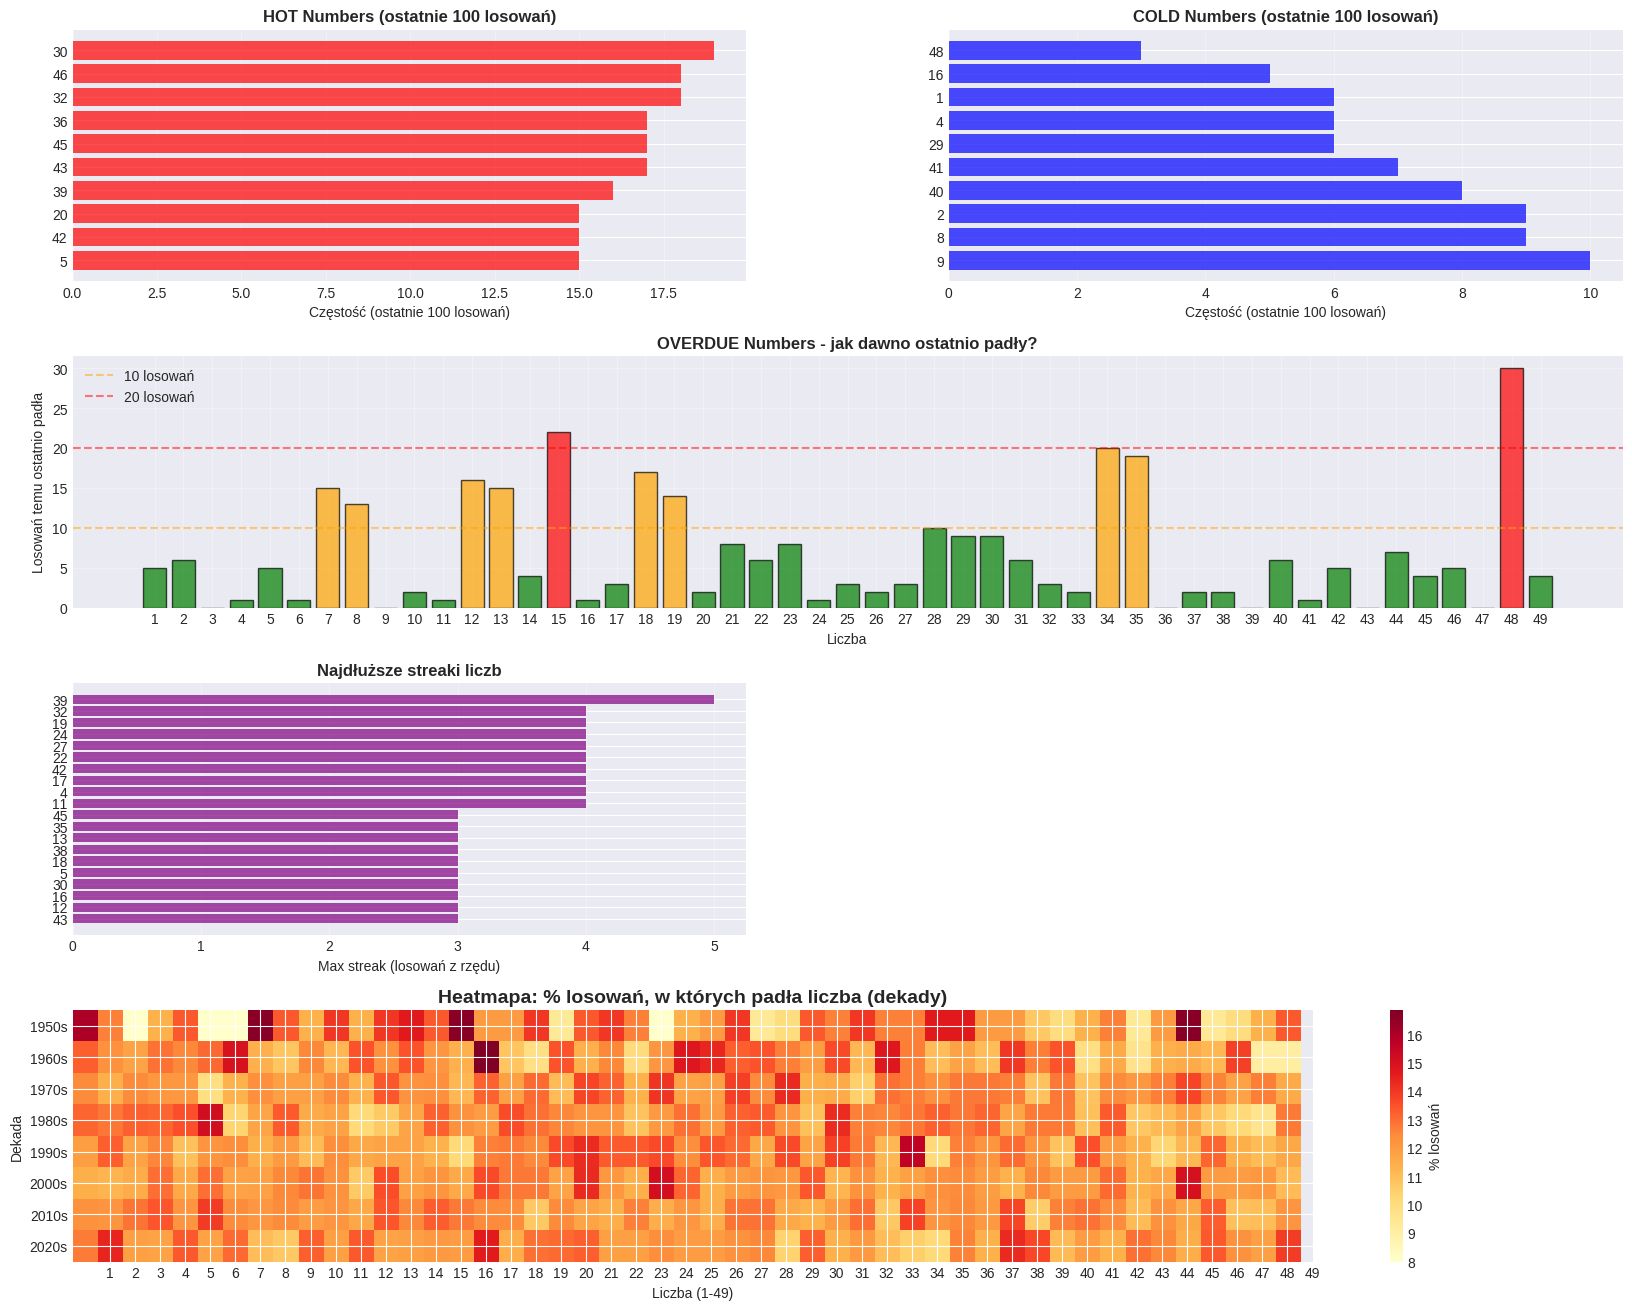

In [83]:
#Wizualizacje

fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.3)

# Hot/Cold
ax1 = fig.add_subplot(gs[0, 0])
hot_nums = [x[0] for x in hot_100]
hot_counts = [x[1] for x in hot_100]
ax1.barh(range(len(hot_nums)), hot_counts, color='red', alpha=0.7)
ax1.set_yticks(range(len(hot_nums)))
ax1.set_yticklabels(hot_nums)
ax1.set_xlabel('Częstość (ostatnie 100 losowań)')
ax1.set_title('HOT Numbers (ostatnie 100 losowań)', fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Cold numbers
ax2 = fig.add_subplot(gs[0, 1])
cold_nums = [x[0] for x in cold_100]
cold_counts = [x[1] for x in cold_100]
ax2.barh(range(len(cold_nums)), cold_counts, color='blue', alpha=0.7)
ax2.set_yticks(range(len(cold_nums)))
ax2.set_yticklabels(cold_nums)
ax2.set_xlabel('Częstość (ostatnie 100 losowań)')
ax2.set_title('COLD Numbers (ostatnie 100 losowań)', fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

# Overdue numbers
ax3 = fig.add_subplot(gs[1, :])
overdue_nums = [x[0] for x in overdue_sorted]
overdue_vals = [x[1] for x in overdue_sorted]
colors = ['red' if v > 20 else 'orange' if v > 10 else 'green' for v in overdue_vals]
ax3.bar(overdue_nums, overdue_vals, color=colors, alpha=0.7, edgecolor='black')
ax3.set_xlabel('Liczba')
ax3.set_xticks(range(1, 50))
ax3.set_ylabel('Losowań temu ostatnio padła')
ax3.set_title('OVERDUE Numbers - jak dawno ostatnio padły?', fontweight='bold')
ax3.axhline(10, color='orange', linestyle='--', alpha=0.5, label='10 losowań')
ax3.axhline(20, color='red', linestyle='--', alpha=0.5, label='20 losowań')
ax3.legend()
ax3.grid(alpha=0.3)

# Streaki
ax4 = fig.add_subplot(gs[2, 0])
streak_nums = [x[0] for x in streaki_sorted[:20]]
streak_vals = [x[1] for x in streaki_sorted[:20]]
ax4.barh(range(len(streak_nums)), streak_vals, color='purple', alpha=0.7)
ax4.set_yticks(range(len(streak_nums)))
ax4.set_yticklabels(streak_nums)
ax4.set_xlabel('Max streak (losowań z rzędu)')
ax4.set_title('Najdłuższe streaki liczb', fontweight='bold')
ax4.invert_yaxis()
ax4.grid(axis='x', alpha=0.3)


# Heatmapa częstości w dekadach
ax6 = fig.add_subplot(gs[3, :])
dekady = sorted(df['dekada'].unique())
macierz_dekady = np.zeros((len(dekady), 49), dtype=float)

losowania_na_dekade = df.groupby('dekada').size()

for idx_d, dekada in enumerate(dekady):
    df_dekada = df[df['dekada'] == dekada]
    n_los = losowania_na_dekade.loc[dekada]
    for num in range(1, 50):
        count = (df_dekada[kolumny_liczb]==num).sum().sum()
        macierz_dekady[idx_d, num-1] = 100.0 * count / n_los

im = ax6.imshow(macierz_dekady, cmap='YlOrRd', aspect='auto')
ax6.set_yticks(range(len(dekady)))
ax6.set_yticklabels([f"{d}s" for d in dekady])
ax6.set_xlabel('Liczba (1-49)')
ax6.set_ylabel('Dekada')
ax6.set_title('Heatmapa: % losowań, w których padła liczba (dekady)', fontsize=14, fontweight='bold')
ax6.set_xticks(range(1, 50))
plt.colorbar(im, ax=ax6, label='% losowań')

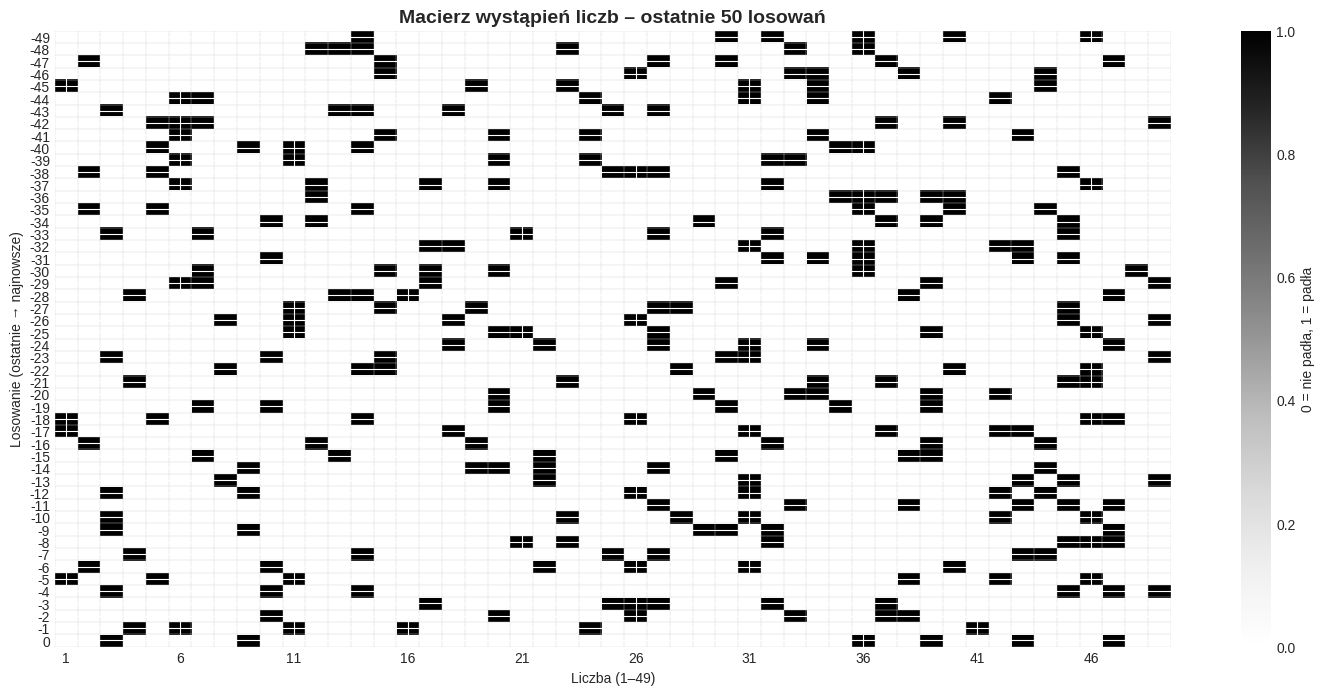

In [84]:
N = 50  # ile ostatnich losowań pokazujemy

df_last = df.sort_values("data").tail(N)

macierz = np.zeros((N, 49), dtype=int)

for i, (_, row) in enumerate(df_last.iterrows()):
    for num in row[kolumny_liczb]:
        macierz[i, num - 1] = 1

fig, ax = plt.subplots(figsize=(18, 8))

im = ax.imshow(macierz, cmap="Greys", aspect="auto")

ax.set_xlabel("Liczba (1–49)")
ax.set_ylabel("Losowanie (ostatnie → najnowsze)")
ax.set_title("Macierz wystąpień liczb – ostatnie 50 losowań", fontsize=14, fontweight="bold")

# Oś X: liczby 1–49
ax.set_xticks(range(0, 49, 5))
ax.set_xticklabels(range(1, 50, 5))

# Oś Y: indeksy losowań (od najstarszego do najnowszego)
ax.set_yticks(range(N))
ax.set_yticklabels(range(-N + 1, 1))

# cienkie linie siatki
ax.set_xticks(np.arange(-.5, 49, 1), minor=True)
ax.set_yticks(np.arange(-.5, N, 1), minor=True)
ax.grid(which="minor", color="lightgray", linestyle='-', linewidth=0.3)
ax.tick_params(which="minor", bottom=False, left=False)

plt.colorbar(im, ax=ax, label="0 = nie padła, 1 = padła")
plt.show()


In [85]:
# Czy granie na hot numbers pomaga?

def symuluj_strategie(strategy='hot', okno=100, test_n=100):
    trafienia = []

    # Zacznij od losowania nr 'okno'
    for idx in range(okno, len(df) - test_n):
        # Ustal hot/cold based on previous 'okno' losowań
        df_okno = df.iloc[idx-okno:idx]
        wszystkie = []
        for _, row in df_okno.iterrows():
            wszystkie.extend(row[kolumny_liczb].values)
        counter = Counter(wszystkie)

        if strategy == 'hot':
            # Wybierz top 6 hot numbers
            wybrane = [num for num, _ in counter.most_common(6)]
        else:  # cold
            # Wybierz 6 least common
            all_counts = [(num, counter.get(num, 0)) for num in range(1, 50)]
            all_counts.sort(key=lambda x: x[1])
            wybrane = [num for num, _ in all_counts[:6]]

        # Sprawdź następne losowanie
        nastepne = set(df.iloc[idx][kolumny_liczb].values)
        trafione = len(set(wybrane) & nastepne)
        trafienia.append(trafione)

    return trafienia

# Testujemy różne strategie
trafienia_hot = symuluj_strategie('hot', okno=100, test_n=1000)
trafienia_cold = symuluj_strategie('cold', okno=100, test_n=1000)

# Losowa strategia (baseline)
np.random.seed(42)
trafienia_random = []
for _ in range(len(trafienia_hot)):
    wybrane = np.random.choice(range(1, 50), size=6, replace=False)
    # Symuluj losowanie
    prawdziwe = np.random.choice(range(1, 50), size=6, replace=False)
    trafione = len(set(wybrane) & set(prawdziwe))
    trafienia_random.append(trafione)

print(f"\nWyniki symulacji ({len(trafienia_hot)} losowań):")
print(f"Strategia HOT:    średnio {np.mean(trafienia_hot):.3f} trafień")
print(f"Strategia COLD:   średnio {np.mean(trafienia_cold):.3f} trafień")
print(f"Strategia RANDOM: średnio {np.mean(trafienia_random):.3f} trafień")

# Test statystyczny
from scipy.stats import ttest_ind
t_hot_vs_random, p_hot = ttest_ind(trafienia_hot, trafienia_random)
t_cold_vs_random, p_cold = ttest_ind(trafienia_cold, trafienia_random)

print(f"\nTest t-Studenta (HOT vs RANDOM): t={t_hot_vs_random:.4f}, p={p_hot:.6f}")
if p_hot > 0.05:
    print("Brak istotnej różnicy - HOT nie daje przewagi!")
else:
    print("Istotna różnica - ale sprawdź czy to nie artefakt!")

print(f"\nTest t-Studenta (COLD vs RANDOM): t={t_cold_vs_random:.4f}, p={p_cold:.6f}")
if p_cold > 0.05:
    print("Brak istotnej różnicy - COLD nie daje przewagi!")
else:
    print("Istotna różnica - ale sprawdź czy to nie artefakt!")


Wyniki symulacji (6191 losowań):
Strategia HOT:    średnio 0.732 trafień
Strategia COLD:   średnio 0.750 trafień
Strategia RANDOM: średnio 0.753 trafień

Test t-Studenta (HOT vs RANDOM): t=-1.5322, p=0.125504
Brak istotnej różnicy - HOT nie daje przewagi!

Test t-Studenta (COLD vs RANDOM): t=-0.1888, p=0.850275
Brak istotnej różnicy - COLD nie daje przewagi!
